# Notebook 1 — Understanding the Alberta Electricity Market

## Overview

This notebook establishes the operational context for the project. It validates the common dataset, describes Alberta's long-term supply and demand transition, summarizes normal operating patterns and high-price hours, and develops hypotheses for forecasting work.

The results are descriptive. They identify patterns and research directions but do not establish causality or predictive value.

## Executive Summary

- Alberta Internal Load increased by roughly 10% between 2015 and 2024.
- Coal fell from about 64% to less than 3% of total system generation as gas, wind, and solar expanded.
- The reported supply stack expanded by approximately 6.8 GW, yet high-price hours became more frequent after 2021.
- The 2021–2023 period forms a distinct high-price regime rather than a collection of isolated anomalies.
- Net load exhibits the strongest nonlinear relationship with pool price among the variables examined, although substantial dispersion indicates that additional market-state variables remain necessary.
- Imports, gas prices, outages, and renewable output remain state-dependent and require lagged, interaction, and availability-aware tests.
- These findings motivate time-aware tests of system margin, net load, intertie saturation, fuel-cost interactions, and seasonal regimes.

## 1. Import and Data Validation

### 1.1 Import Libraries and Load Data


In [1]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import (
    PA_TABLE_PARQUET,
    INTERTIES_HOUR_AHEAD_PARQUET,
    INTERTIE_CAPABILITY_PARQUET,
    GENERATION_PARQUET,
    OUTAGES_PARQUET,
    CALENDAR_FEATURES,
    LOAD_WEATHER_FEATURES,
    MARKET_FEATURES,
    RENEWABLE_WEATHER_FEATURES,
    RANDOM_SEED,
)

# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------
# Load processed datasets
# ---------------------------------------------------------------------

pa_hourly = pd.read_parquet(PA_TABLE_PARQUET)
interties_hour_ahead = pd.read_parquet(INTERTIES_HOUR_AHEAD_PARQUET)
intertie_capability = pd.read_parquet(INTERTIE_CAPABILITY_PARQUET)
generation = pd.read_parquet(GENERATION_PARQUET)
outages = pd.read_parquet(OUTAGES_PARQUET)
calendar = pd.read_parquet(CALENDAR_FEATURES)
weather = pd.read_parquet(LOAD_WEATHER_FEATURES)
market = pd.read_parquet(MARKET_FEATURES)
renewables = pd.read_parquet(RENEWABLE_WEATHER_FEATURES)

### 1.2 Dataset Overview

In [2]:
# ---------------------------------------------------------------------
# Summarize the processed datasets
# ---------------------------------------------------------------------

summary = []

datasets = {
    "pa_hourly": pa_hourly,
    "interties": interties_hour_ahead,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "outages": outages,
    "calendar": calendar,
    "weather": weather,
    "market": market,
    "renewables": renewables,
}

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Start": df["timestamp_utc"].min(),
        "End": df["timestamp_utc"].max(),
        "Duplicate timestamps": df["timestamp_utc"].duplicated().sum(),
        "Missing values": int(df.isna().sum().sum()),
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1e6, 2),
    })

dataset_summary = pd.DataFrame(summary)

dataset_summary

,Dataset,Rows,Columns,Start,End,Duplicate timestamps,Missing values,Memory (MB)
0,pa_hourly,100055,5,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,0,4.00
1,interties,136583,8,2010-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00,0,62786,8.74
2,intertie_capability,100033,9,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,0,7.20
3,generation,100055,61,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,985430,48.83
4,outages,100033,13,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,197686,10.40
5,calendar,100776,46,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0,19.16
6,weather,87672,73,2015-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00,0,110326,45.68
7,market,100055,264,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,739383,185.12
8,renewables,100776,51,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,44295,41.12


In [3]:
# ---------------------------------------------------------------------
# Summarize missing values by dataset
# ---------------------------------------------------------------------

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing.gt(0)].sort_values(ascending=False)

    print(
        f"{name}: "
        f"{len(missing)} columns with missing values, "
        f"{missing.sum():,} missing observations"
    )

    if not missing.empty:
        display(
            missing.head(5).to_frame("missing_rows")
        )

pa_hourly: 0 columns with missing values, 0 missing observations
interties: 3 columns with missing values, 62,786 missing observations


,missing_rows
export_mt,31391
import_mt,31391
hour_ahead_price_forecast,4


intertie_capability: 0 columns with missing values, 0 missing observations
generation: 25 columns with missing values, 985,430 missing observations


,missing_rows
gas_fired_steam_system_available,53352
gas_fired_steam_system_generation,53352
gas_fired_steam_maximum_capacity,53352
gas_fired_steam_system_capacity,53352
gas_fired_steam_total_generation,53352


outages: 6 columns with missing values, 197,686 missing observations


...

,missing_rows
load_weighted_heat_index_c,86824
load_weighted_wind_chill_c,23456
load_temperature_change_24h_c,24
load_temperature_change_12h_c,12
load_temperature_change_6h_c,6


market: 201 columns with missing values, 739,383 missing observations


,missing_rows
gas_fired_steam_outage,53374
storage_outage,51165
storage_outage_mw,51165
dual_fuel_outage,50037
solar_outage,25678


renewables: 1 columns with missing values, 44,295 missing observations


,missing_rows
solar_clear_sky_radiation_ratio,44295


#### Dataset Overview

No processed dataset contains duplicate timestamps. The pa_hourly, intertie capability, and calendar datasets are complete, while the hour-ahead price forecast in the interties dataset contains only four missing observations. Intertie missingness is concentrated before the Montana–Alberta Tie Line entered service and therefore reflects a historical reporting boundary rather than random data loss. Generation and outage gaps are primarily structural, arising from technology entry, retirement, or changes in AESO reporting classifications. Weather missingness largely corresponds to variables that are only physically defined under specific meteorological conditions, while the remaining gaps occur in lagged and rolling features where sufficient historical observations are unavailable by construction. Overall, the missingness is structured and explainable rather than indicative of broad data-quality problems.

### 1.3 Validate External Data Coverage

In [4]:
# ---------------------------------------------------------------------
# Validate historical Montana intertie coverage
# ---------------------------------------------------------------------

# Identify the first reported Montana import and export observations.
print(
    interties_hour_ahead.loc[
        interties_hour_ahead["import_mt"].notna(),
        "timestamp_utc",
    ].min()
)

print(
    interties_hour_ahead.loc[
        interties_hour_ahead["export_mt"].notna(),
        "timestamp_utc",
    ].min()
)

# Confirm that no missing values remain after historical reporting begins.
cutoff = pd.Timestamp("2013-08-01 06:00:00", tz="UTC")

mt_missing = (
    interties_hour_ahead.loc[
        interties_hour_ahead["timestamp_utc"] >= cutoff,
        ["import_mt", "export_mt"],
    ]
    .isna()
    .sum()
)

print(mt_missing)

2013-08-01 06:00:00+00:00
2013-08-01 06:00:00+00:00
import_mt    0
export_mt    0
dtype: int64


#### Montana Intertie Reporting

Montana imports and exports are unavailable before August 2013 because the intertie was not yet operational and publicly reported. Both series are complete from 2013-08-01 06:00 UTC, so the earlier values represent a reporting boundary rather than random missingness.

In [5]:
# ---------------------------------------------------------------------
# Validate generation coverage by reported fuel category
# ---------------------------------------------------------------------

generation_coverage = []

generation_category_columns = [
    column
    for column in generation.columns
    if column.endswith("_system_generation")
    and column != "total_system_generation"
]

for column in generation_category_columns:
    reported = generation[column].notna()
    fuel = column.removesuffix("_system_generation").replace("_", " ").title()

    generation_coverage.append({
        "fuel_category": fuel,
        "first_reported": generation.loc[reported, "timestamp_utc"].min(),
        "last_reported": generation.loc[reported, "timestamp_utc"].max(),
        "observed_hours": int(reported.sum()),
        "coverage_pct": reported.mean() * 100,
    })

generation_coverage = (
    pd.DataFrame(generation_coverage)
    .sort_values("first_reported")
    .reset_index(drop=True)
)

display(generation_coverage.round({"coverage_pct": 2}))


,fuel_category,first_reported,last_reported,observed_hours,coverage_pct
0,Coal,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,83255,83.21
1,Cogeneration,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
2,Combined Cycle,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
3,Hydro,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
4,Other,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
5,Simple Cycle,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
6,Wind,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,100055,100.00
7,Solar,2017-12-05 07:00:00+00:00,2026-06-01 05:00:00+00:00,74399,74.36
8,Dual Fuel,2018-03-05 07:00:00+00:00,2024-07-12 05:00:00+00:00,49920,49.89
9,Storage,2020-11-01 06:00:00+00:00,2026-06-01 05:00:00+00:00,48912,48.89


#### Generation Dataset Coverage

Coverage changes align with Alberta's fleet transition and AESO classification changes. Solar begins in December 2017, storage in November 2020, and Gas-Fired Steam becomes a separate category in 2021. Dual Fuel is reported from 2018 to July 2024, while Coal ends in July 2024.

Within each fuel category, generation and capacity measures share the same coverage window. These blocks are therefore treated as structurally unavailable, not automatically imputed. The net-load calculation makes one narrow exception: pre-reporting utility-scale solar is explicitly interpreted as zero output.

### 1.4 Merge

In [6]:
# ---------------------------------------------------------------------
# Configure the master dataset merge
# ---------------------------------------------------------------------

merge_key = "timestamp_utc"

# Calendar is the canonical source for timestamp-derived features.
# Placing it first preserves its values when identical calendar columns
# also appear in another feature dataset.
merge_datasets = {
    "calendar": calendar,
    "market": market,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "weather": weather,
    "renewables": renewables,
}

reconciled_columns = []


# ---------------------------------------------------------------------
# Validate merge keys and timestamp uniqueness
# ---------------------------------------------------------------------

for dataset_name, df in merge_datasets.items():

    if merge_key not in df.columns:
        raise KeyError(
            f"{merge_key!r} is missing from dataset "
            f"{dataset_name!r}."
        )

    duplicate_timestamps = df[merge_key].duplicated().sum()

    if duplicate_timestamps:
        raise ValueError(
            f"Dataset {dataset_name!r} contains "
            f"{duplicate_timestamps:,} duplicate timestamps."
        )


# ---------------------------------------------------------------------
# Initialize the master dataset with the canonical calendar table
# ---------------------------------------------------------------------

master = (
    merge_datasets["calendar"]
    .sort_values(merge_key)
    .copy()
)


# ---------------------------------------------------------------------
# Merge feature datasets and reconcile overlapping columns
# ---------------------------------------------------------------------

for dataset_name, df in list(merge_datasets.items())[1:]:

    incoming = (
        df
        .sort_values(merge_key)
        .copy()
    )

    overlapping_columns = sorted(
        (set(master.columns) & set(incoming.columns))
        - {merge_key}
    )

    columns_to_drop = []

    for column in overlapping_columns:

        comparison = (
            master[[merge_key, column]]
            .merge(
                incoming[[merge_key, column]],
                on=merge_key,
                how="inner",
                suffixes=("_master", "_incoming"),
                validate="one_to_one",
            )
        )

        master_col = f"{column}_master"
        incoming_col = f"{column}_incoming"

        values_match = (
            comparison[master_col].eq(
                comparison[incoming_col]
            )
            | (
                comparison[master_col].isna()
                & comparison[incoming_col].isna()
            )
        )

        if not values_match.all():

            discrepancies = comparison.loc[
                ~values_match.fillna(False),
                [
                    merge_key,
                    master_col,
                    incoming_col,
                ],
            ]

            display(discrepancies.head(50))

            raise ValueError(
                f"Column {column!r} exists in both master and "
                f"{dataset_name!r}, but contains "
                f"{len(discrepancies):,} conflicting observations."
            )

        # Retain the canonical version already present in master.
        columns_to_drop.append(column)

        reconciled_columns.append({
            "incoming_dataset": dataset_name,
            "column": column,
        })

    incoming = incoming.drop(columns=columns_to_drop)

    # Retain only timestamps covered by every required dataset.
    master = master.merge(
        incoming,
        on=merge_key,
        how="inner",
        validate="one_to_one",
    )


# ---------------------------------------------------------------------
# Finalize the master dataset
# ---------------------------------------------------------------------

master = (
    master
    .sort_values(merge_key)
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Validate the completed merge
# ---------------------------------------------------------------------

calendar_columns = [
    column
    for column in calendar.columns
    if column != merge_key
]

missing_calendar_columns = [
    column
    for column in calendar_columns
    if column not in master.columns
]

unexpected_suffix_columns = [
    column
    for column in master.columns
    if column.endswith(("_x", "_y"))
]

duplicate_master_timestamps = (
    master[merge_key]
    .duplicated()
    .sum()
)

if duplicate_master_timestamps:
    raise ValueError(
        "The completed master dataset contains "
        f"{duplicate_master_timestamps:,} duplicate timestamps."
    )

if missing_calendar_columns:
    raise ValueError(
        "The following canonical calendar columns are missing "
        f"from master: {missing_calendar_columns}"
    )

if unexpected_suffix_columns:
    raise ValueError(
        "Unexpected merge suffix columns remain: "
        f"{unexpected_suffix_columns}"
    )


# ---------------------------------------------------------------------
# Display a concise master-dataset audit
# ---------------------------------------------------------------------

master_audit = pd.Series({
    "Rows": len(master),
    "Columns": master.shape[1],
    "Start": master[merge_key].min(),
    "End": master[merge_key].max(),
    "Duplicate timestamps": duplicate_master_timestamps,
    "Missing observations": int(master.isna().sum().sum()),
    "Calendar fields retained": (
        f"{len(calendar_columns) - len(missing_calendar_columns)}"
        f"/{len(calendar_columns)}"
    ),
    "Conflicting-overlapping fields": 0,
    "Unexpected merge suffixes": len(unexpected_suffix_columns),
})

display(master_audit.to_frame("value"))

,value
Rows,87665
Columns,452
Start,2015-01-01 07:00:00+00:00
End,2024-12-31 23:00:00+00:00
Duplicate timestamps,0
Missing observations,1236776
Calendar fields retained,45/45
Conflicting-overlapping fields,0
Unexpected merge suffixes,0


In [7]:
# ---------------------------------------------------------------------
# Audit missingness in the master dataset
# ---------------------------------------------------------------------

missing_audit = (
    master
    .isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
)

missing_audit["missing_pct"] = (
    missing_audit["missing_rows"]
    / len(master)
    * 100
)

missing_audit = (
    missing_audit
    .query("missing_rows > 0")
    .sort_values(
        ["missing_pct", "missing_rows"],
        ascending=False,
    )
)

print(
    f"Columns with missing values: "
    f"{len(missing_audit):,} / {master.shape[1]:,}"
)

display(
    missing_audit.head(10).style.set_table_attributes(
        'style="display:block; max-height:400px; overflow:auto;"'
    )
)

Columns with missing values: 202 / 452


,missing_rows,missing_pct
load_weighted_heat_index_c,86817,99.032681
gas_fired_steam_outage,53352,60.858952
gas_fired_steam_system_generation,53352,60.858952
gas_fired_steam_total_generation,53352,60.858952
gas_fired_steam_system_available,53352,60.858952
gas_fired_steam_system_capacity,53352,60.858952
gas_fired_steam_maximum_capacity,53352,60.858952
storage_outage,51143,58.339132
storage_outage_mw,51143,58.339132
storage_system_generation,51143,58.339132


#### Merge Missingness Audit

The merge introduces no unexpected missingness. Remaining gaps reflect four expected mechanisms: reporting boundaries for technologies introduced, retired, or reclassified during the study period; weather variables that are only defined under specific meteorological conditions; undefined solar clear-sky ratios when the denominator is zero, particularly at night; and lag or rolling-window features that require prior observations by construction.

The merge also validates timestamp uniqueness, reconciles overlapping columns, and preserves the canonical calendar fields. The resulting master DataFrame is the authoritative analytical dataset for every section that follows. Analysis-specific variables are created separately and are never appended to master.

> Once the canonical master dataset is finalized, the merge logic can move to a dedicated builder and this notebook can simply load and audit the resulting artifact.

In [8]:
# ---------------------------------------------------------------------
# Confirm the common analytical sample and annual coverage
# ---------------------------------------------------------------------

print(
    "Primary analysis sample:",
    master["timestamp_utc"].min(),
    "to",
    master["timestamp_utc"].max(),
)

annual_analysis_coverage = (
    master.groupby("year_alberta")
    .agg(
        first_timestamp=("timestamp_utc", "min"),
        last_timestamp=("timestamp_utc", "max"),
        observed_hours=("timestamp_utc", "size"),
    )
)

annual_analysis_coverage["expected_hours"] = (
    annual_analysis_coverage.index.map(
        lambda year: 8784
        if pd.Timestamp(year=year, month=12, day=31).is_leap_year
        else 8760
    )
)

annual_analysis_coverage["coverage_pct"] = (
    annual_analysis_coverage["observed_hours"]
    / annual_analysis_coverage["expected_hours"]
    * 100
)

annual_analysis_coverage["coverage_note"] = np.where(
    annual_analysis_coverage["observed_hours"]
    == annual_analysis_coverage["expected_hours"],
    "Complete local calendar year",
    "Partial local calendar year",
)

display(annual_analysis_coverage.round({"coverage_pct": 3}))


Primary analysis sample: 2015-01-01 07:00:00+00:00 to 2024-12-31 23:00:00+00:00


,first_timestamp,last_timestamp,observed_hours,expected_hours,coverage_pct,coverage_note
year_alberta,,,,,,
2015,2015-01-01 07:00:00+00:00,2016-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2016,2016-01-01 07:00:00+00:00,2017-01-01 06:00:00+00:00,8784,8784,100.00,Complete local calendar year
2017,2017-01-01 07:00:00+00:00,2018-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2018,2018-01-01 07:00:00+00:00,2019-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2019,2019-01-01 07:00:00+00:00,2020-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2020,2020-01-01 07:00:00+00:00,2021-01-01 06:00:00+00:00,8784,8784,100.00,Complete local calendar year
2021,2021-01-01 07:00:00+00:00,2022-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2022,2022-01-01 07:00:00+00:00,2023-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year
2023,2023-01-01 07:00:00+00:00,2024-01-01 06:00:00+00:00,8760,8760,100.00,Complete local calendar year


In [9]:
# ---------------------------------------------------------------------
# Validate continuous hourly timestamp coverage
# ---------------------------------------------------------------------

# The endpoints are already timezone-aware UTC timestamps.
expected_timestamps = pd.date_range(
    start=master["timestamp_utc"].min(),
    end=master["timestamp_utc"].max(),
    freq="h",
)

observed_timestamps = pd.DatetimeIndex(
    master["timestamp_utc"].sort_values()
)

missing_timestamps = expected_timestamps.difference(observed_timestamps)
unexpected_timestamps = observed_timestamps.difference(expected_timestamps)

timestamp_gaps = (
    master["timestamp_utc"]
    .sort_values()
    .diff()
)

irregular_intervals = timestamp_gaps.iloc[1:].ne(
    pd.Timedelta(hours=1)
).sum()

print(f"Expected timestamps:   {len(expected_timestamps):,}")
print(f"Observed timestamps:   {len(observed_timestamps):,}")
print(f"Missing timestamps:    {len(missing_timestamps):,}")
print(f"Unexpected timestamps: {len(unexpected_timestamps):,}")
print(f"Irregular intervals:   {irregular_intervals:,}")

if (
    len(missing_timestamps)
    or len(unexpected_timestamps)
    or irregular_intervals
):
    raise ValueError(
        "The master dataset does not contain continuous hourly coverage."
    )


Expected timestamps:   87,665
Observed timestamps:   87,665
Missing timestamps:    0
Unexpected timestamps: 0
Irregular intervals:   0


#### Common Sample Coverage

All sections use the same 2015–2024 master sample. The final seven local-calendar hours of 2024 fall beyond the last UTC timestamp, leaving 8,777 of 8,784 hours (99.92%). The continuity audit confirms that every expected UTC hour between the sample endpoints is present.

## Section 2 — Long-Term Evolution of Alberta's Electricity Market

Before interpreting the data, it is useful to state the market mechanism. Alberta operates an energy-only electricity market in which generators submit offers and the market clears at the marginal accepted offer. All dispatched generators receive the same pool price. Prices therefore reflect both production costs and system scarcity. When available supply comfortably exceeds demand, prices tend to remain near marginal operating costs. As reserve margins tighten, increasingly expensive generators can set price, and a few hundred MW of shortage can move the pool price from ordinary levels to scarcity-price levels.

Alberta simultaneously experienced demand growth, rapid coal retirement, expansion of gas and renewable generation, increasing interconnection utilization, and substantial changes in reported market structure. These changes altered both the composition of supply and the operating conditions under which prices are formed, motivating separate analysis of system state rather than reliance on historical averages alone.

We first examine how demand, generation, fleet capability, and intertie use changed before turning to hourly operation.

### 2.1 How Has Electricity Demand Changed?


In [10]:
# ---------------------------------------------------------------------
# Summarize annual electricity demand
# ---------------------------------------------------------------------

load_col = "ail_mw"

annual_load = (
    master.groupby("year_alberta")[load_col]
    .agg(
        average_load_mw="mean",
        median_load_mw="median",
        peak_load_mw="max",
        minimum_load_mw="min",
    )
)

annual_load["annual_energy_twh"] = (
    master.groupby("year_alberta")[load_col].sum() / 1_000_000
)

annual_load["average_load_growth_pct"] = (
    annual_load["average_load_mw"].pct_change() * 100
)

annual_load.round(2)

,average_load_mw,median_load_mw,peak_load_mw,minimum_load_mw,annual_energy_twh,average_load_growth_pct
year_alberta,,,,,,
2015,9161.75,9168.0,11229,7203,80.26,NaN
2016,9057.37,9080.0,11458,6595,79.56,-1.14
2017,9426.08,9401.0,11473,7600,82.57,4.07
2018,9740.86,9749.5,11697,7819,85.33,3.34
2019,9694.67,9677.0,11471,8024,84.93,-0.47
2020,9462.05,9437.0,11698,7579,83.11,-2.40
2021,9727.59,9653.5,11729,7976,85.21,2.81
2022,9882.61,9851.0,12193,8110,86.57,1.59
2023,9850.81,9847.0,11572,7873,86.29,-0.32


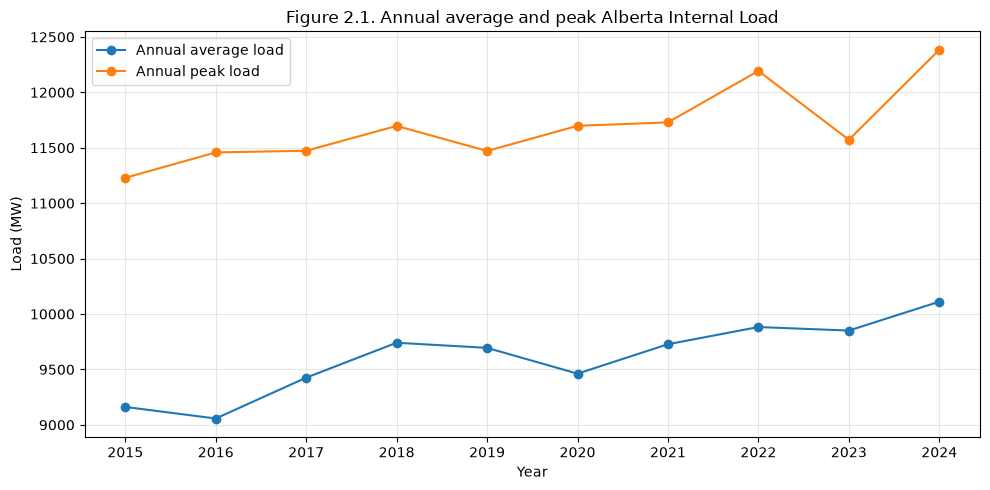

In [11]:
# ---------------------------------------------------------------------
# Visualize long-term demand trends
# ---------------------------------------------------------------------

plot_df = annual_load.copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df.index,
    plot_df["average_load_mw"],
    marker="o",
    label="Annual average load",
)

ax.plot(
    plot_df.index,
    plot_df["peak_load_mw"],
    marker="o",
    label="Annual peak load",
)

ax.set_title("Figure 2.1. Annual average and peak Alberta Internal Load")
ax.set_xlabel("Year")
ax.set_ylabel("Load (MW)")
ax.set_xticks(plot_df.index)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

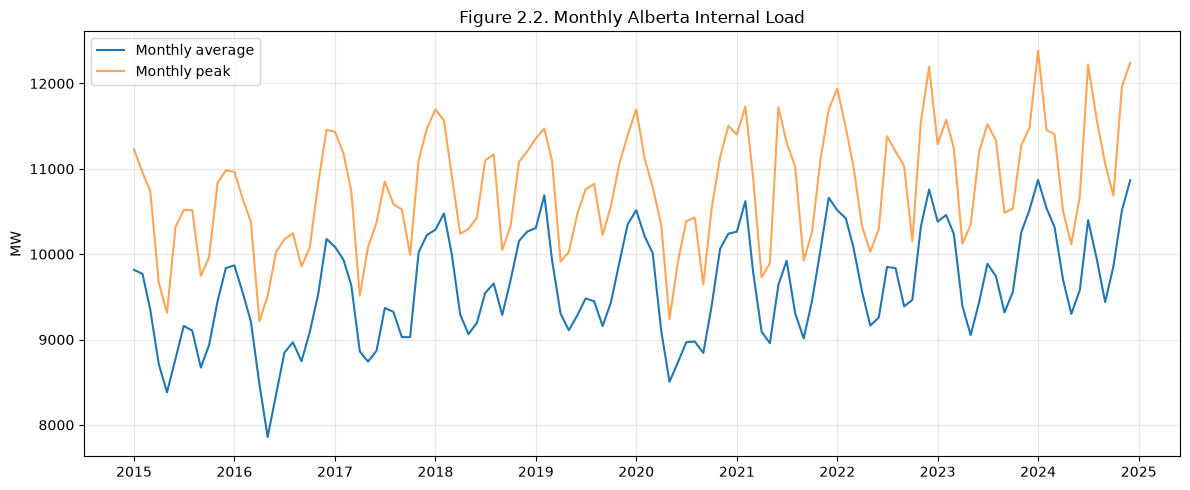

In [12]:
# ---------------------------------------------------------------------
# Visualize monthly demand evolution
# ---------------------------------------------------------------------

monthly_load = (
    master.set_index("timestamp_utc")[load_col]
    .resample("MS")
    .agg(["mean", "max"])
    .rename(
        columns={
            "mean": "average_load_mw",
            "max": "peak_load_mw",
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_load.index,
    monthly_load["average_load_mw"],
    label="Monthly average",
)

ax.plot(
    monthly_load.index,
    monthly_load["peak_load_mw"],
    alpha=0.7,
    label="Monthly peak",
)

ax.set_title("Figure 2.2. Monthly Alberta Internal Load")
ax.set_xlabel("")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Electricity Demand

Average, peak, and minimum Alberta Internal Load increased over 2015–2024, although growth was uneven. Winter consistently records the highest demand, shoulder seasons the lowest, and recent summers show increasingly important peaks. The simultaneous increase in minimum, average, and peak demand suggests that growth has occurred across the system rather than being confined to periods of peak consumption. Despite higher demand levels, Alberta's broad seasonal and intraday load structure remained relatively stable over the study period. Within this sample, changes in market outcomes therefore appear more likely to reflect the interaction between a higher load baseline and evolving supply conditions than a wholesale shift in the timing of demand.

### 2.2 How Has the Generation Mix Changed?

In [13]:
# ---------------------------------------------------------------------
# Define generation categories for analysis
# ---------------------------------------------------------------------

GENERATION_COLUMNS = {
    "Coal": "coal_system_generation",
    "Cogeneration": "cogeneration_system_generation",
    "Combined Cycle": "combined_cycle_system_generation",
    "Dual Fuel": "dual_fuel_system_generation",
    "Gas-Fired Steam": "gas_fired_steam_system_generation",
    "Hydro": "hydro_system_generation",
    "Other": "other_system_generation",
    "Simple Cycle": "simple_cycle_system_generation",
    "Solar": "solar_system_generation",
    "Storage": "storage_system_generation",
    "Wind": "wind_system_generation",
}

In [14]:
# ---------------------------------------------------------------------
# Summarize annual generation by fuel category
# ---------------------------------------------------------------------

annual_generation_gwh = (
    master
    .groupby("year_alberta")[list(GENERATION_COLUMNS.values())]
    .sum(min_count=1)
    .div(1_000)
    .rename(
        columns={
            column: fuel
            for fuel, column in GENERATION_COLUMNS.items()
        }
    )
)


display(annual_generation_gwh.round(1))

,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
year_alberta,,,,,,,,,,,
2015,39392.8,10357.8,5033.8,NaN,NaN,1708.2,570.3,703.8,NaN,NaN,4089.2
2016,38424.0,10427.4,5943.7,NaN,NaN,1733.0,609.1,741.0,NaN,NaN,4405.1
2017,37138.6,10933.4,7246.4,NaN,NaN,1887.2,515.8,888.1,0.1,NaN,4486.3
2018,28523.0,14066.5,9187.4,473.9,NaN,1861.2,651.6,2486.5,22.4,NaN,4104.1
2019,27199.9,14227.0,9652.2,708.6,NaN,1995.6,623.2,2815.2,20.3,NaN,4115.8
2020,20164.0,13795.4,10085.5,2243.3,NaN,2035.3,569.7,2453.8,86.3,0.1,6079.4
2021,15404.8,14321.1,9776.1,2606.6,3616.1,1818.2,697.5,3562.1,477.0,0.6,6132.9
2022,9711.9,13907.8,10703.7,597.9,10509.6,1922.6,651.1,3542.2,1163.9,0.7,7315.3
2023,6519.6,13515.3,10884.4,4038.7,10602.5,1688.8,698.0,2436.1,2311.2,1.8,10283.9


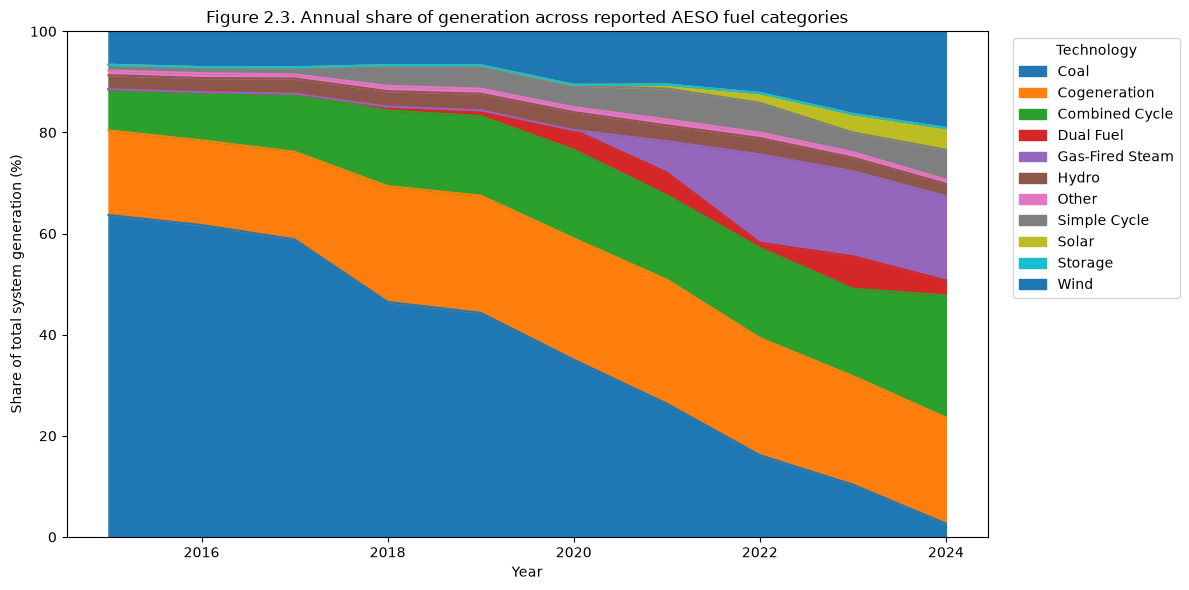

In [15]:
# ---------------------------------------------------------------------
# Reconcile reported categories and visualize annual generation shares
# ---------------------------------------------------------------------

annual_total_system_generation_gwh = (
    master.groupby("year_alberta")["total_system_generation"]
    .sum(min_count=1)
    .div(1_000)
)

annual_generation_share = (
    annual_generation_gwh
    .div(annual_total_system_generation_gwh, axis=0)
    .mul(100)
)

annual_generation_share_plot = annual_generation_share.fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

annual_generation_share_plot.plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Figure 2.3. Annual share of generation across reported AESO fuel categories")
ax.set_xlabel("Year")
ax.set_ylabel("Share of total system generation (%)")
ax.set_ylim(0, 100)
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


#### Generation Mix

Coal fell from roughly two-thirds of recorded generation in 2015 to less than 3% in 2024. Alberta replaced dispatchable coal primarily with dispatchable natural gas while adding substantial wind and solar capacity. Energy shares describe how technologies operated over the year, not their availability during high-price or scarcity hours. Consequently, the changing generation mix alone does not indicate whether system reliability improved or deteriorated, a question examined in later sections.

> AESO fuel classifications changed during the transition. Dual Fuel appears in 2018, Gas-Fired Steam becomes a separate category in 2021, and Coal and Dual Fuel are later removed or reclassified. An unavailable plotted category indicates that no separate AESO category was reported, not necessarily that technically similar generation was absent.

### 2.3 How Has Reported Generation Capacity Changed?

Generation describes operation; reported maximum capacity describes fleet change. Comparing them separates actual output from nameplate capability.

> AESO Maximum Capacity is not firm capacity. Reported capacity can be unavailable because of planned maintenance, forced outages, wind and solar resource conditions, derates, or transmission constraints. A reported 23 GW supply stack does not imply that 23 GW is dispatchable or deliverable in a stressed hour.


In [16]:
# ---------------------------------------------------------------------
# Define AESO maximum-capacity variables by technology
# ---------------------------------------------------------------------

CAPACITY_COLUMNS = {
    "Coal": "coal_maximum_capacity",
    "Cogeneration": "cogeneration_maximum_capacity",
    "Combined Cycle": "combined_cycle_maximum_capacity",
    "Simple Cycle": "simple_cycle_maximum_capacity",
    "Gas-Fired Steam": "gas_fired_steam_maximum_capacity",
    "Hydro": "hydro_maximum_capacity",
    "Other": "other_maximum_capacity",
    "Solar": "solar_maximum_capacity",
    "Storage": "storage_maximum_capacity",
    "Wind": "wind_maximum_capacity",
}

TOTAL_MAXIMUM_CAPACITY_COLUMN = "total_maximum_capacity"

In [17]:
# ---------------------------------------------------------------------
# Summarize year-end maximum generation capacity by technology
# ---------------------------------------------------------------------

capacity_columns = [
    *CAPACITY_COLUMNS.values(),
    TOTAL_MAXIMUM_CAPACITY_COLUMN,
]

year_end_capacity = (
    master
    .sort_values("timestamp_utc")
    .groupby("year_alberta", group_keys=False)
    .tail(1)
    .set_index("year_alberta")
)

annual_capacity_mw = (
    year_end_capacity[capacity_columns]
    .rename(
        columns={
            **{
                column: technology
                for technology, column in CAPACITY_COLUMNS.items()
            },
            TOTAL_MAXIMUM_CAPACITY_COLUMN: "Reported Total",
        }
    )
)

display(annual_capacity_mw.round(1))

,Coal,Cogeneration,Combined Cycle,Simple Cycle,Gas-Fired Steam,Hydro,Other,Solar,Storage,Wind,Reported Total
year_alberta,,,,,,,,,,,
2015,6289.0,4552.0,1758.0,946.0,NaN,894.0,386.0,NaN,NaN,1463.0,16288.0
2016,6299.0,4779.0,1745.0,866.0,NaN,894.0,395.0,NaN,NaN,1445.0,16423.0
2017,6003.0,4986.0,1745.0,866.0,NaN,894.0,392.0,15.0,NaN,1445.0,16346.0
2018,5568.0,4987.0,1790.0,871.0,NaN,894.0,381.0,15.0,NaN,1445.0,16106.0
2019,5183.0,5093.0,1790.0,855.0,NaN,894.0,381.0,15.0,NaN,1781.0,16532.0
2020,4132.0,5131.0,1798.0,1076.0,NaN,894.0,381.0,107.0,30.0,1781.0,16270.0
2021,2530.0,5247.0,1798.0,1182.0,1981.0,894.0,382.0,736.0,50.0,2269.0,17224.0
2022,820.0,5285.0,1852.0,1190.0,2609.0,894.0,402.0,1138.0,70.0,3618.0,18344.0
2023,820.0,5304.0,3052.0,909.0,2609.0,894.0,402.0,1650.0,190.0,4481.0,20777.0


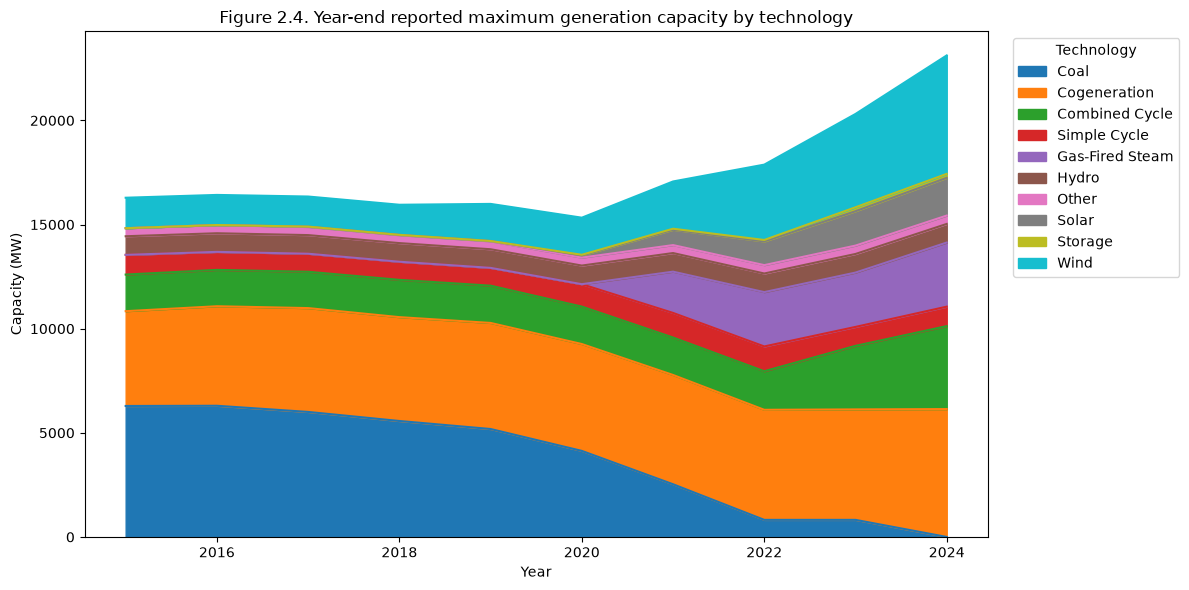

In [18]:
# ---------------------------------------------------------------------
# Visualize changes in maximum generation capacity
# ---------------------------------------------------------------------

technology_columns = list(CAPACITY_COLUMNS.keys())

fig, ax = plt.subplots(figsize=(12, 6))

annual_capacity_mw[technology_columns].plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Figure 2.4. Year-end reported maximum generation capacity by technology")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity (MW)")
ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

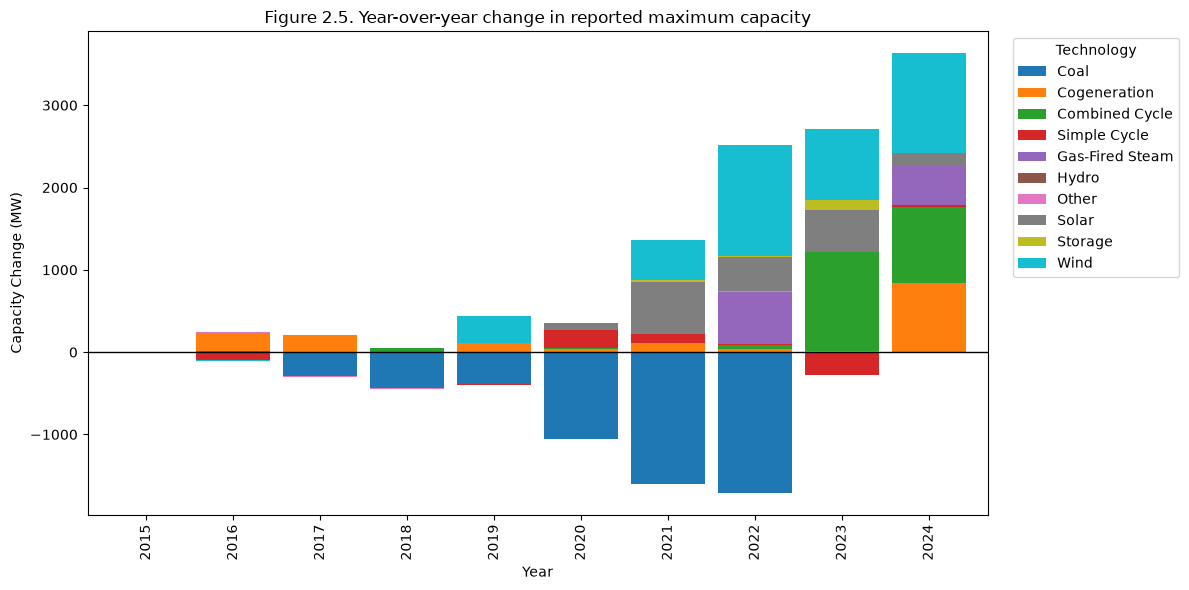

In [19]:
# ---------------------------------------------------------------------
# Visualize year-over-year changes in maximum generation capacity
# ---------------------------------------------------------------------

capacity_change_mw = annual_capacity_mw[
    technology_columns
].diff()

fig, ax = plt.subplots(figsize=(12, 6))

capacity_change_mw.plot(
    kind="bar",
    stacked=True,
    width=0.85,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title("Figure 2.5. Year-over-year change in reported maximum capacity")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity Change (MW)")

ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Reported Maximum Generation Capacity

Reported maximum generation capacity increased from approximately 16.3 GW in 2015 to 23.1 GW in 2024, reflecting Alberta's transition away from coal toward a larger and more diversified generation fleet. Much of the lost coal capacity was replaced by natural gas while wind, solar, and storage also expanded, although some apparent technology-level changes reflect evolving AESO fuel classifications rather than purely physical additions or retirements.
Reported maximum capacity should not be interpreted as the amount of supply available during a high-price or scarcity hour. Thermal units may be offline or derated, renewable output depends on weather and time of day, hydro and storage operate under resource constraints, and intertie transfers are limited by available transmission capability. Consequently, available supply relative to net load, rather than reported maximum capacity alone, provides the more meaningful framework for understanding scarcity and price formation examined in later sections.

### 2.4 How Has Intertie Usage Changed?


In [20]:
# ---------------------------------------------------------------------
# Summarize annual intertie imports and exports
# ---------------------------------------------------------------------

imports_col = "total_imports_mw"
exports_col = "total_exports_mw"
net_imports_col = "net_imports_mw"

annual_interties = (
    master.groupby("year_alberta").agg(
        average_total_imports_mw=(
            imports_col,
            "mean",
        ),
        peak_total_import_mw=(
            imports_col,
            "max",
        ),
        total_import_energy_gwh=(
            imports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_total_exports_mw=(
            exports_col,
            "mean",
        ),
        total_export_energy_gwh=(
            exports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_net_imports_mw=(
            net_imports_col,
            "mean",
        ),
        peak_net_imports_mw=(
            net_imports_col,
            "max",
        ),
        minimum_net_imports_mw=(
            net_imports_col,
            "min",
        ),
        net_importing_hours=(
            "is_net_importing",
            "sum",
        ),
        net_exporting_hours=(
            "is_net_exporting",
            "sum",
        ),
    )
)

annual_interties["net_import_energy_gwh"] = (
    annual_interties["total_import_energy_gwh"]
    - annual_interties["total_export_energy_gwh"]
)

display(annual_interties.round(2))

,average_total_imports_mw,peak_total_import_mw,total_import_energy_gwh,average_total_exports_mw,total_export_energy_gwh,average_net_imports_mw,peak_net_imports_mw,minimum_net_imports_mw,net_importing_hours,net_exporting_hours,net_import_energy_gwh
year_alberta,,,,,,,,,,,
2015,124.57,1002.0,1091.22,74.26,650.55,50.30,1002.0,-877.0,4151,2982,440.67
2016,49.52,769.0,435.02,98.67,866.74,-49.15,729.0,-935.0,2408,3749,-431.72
2017,147.79,998.0,1294.66,116.62,1021.61,31.17,998.0,-935.0,3104,4363,273.05
2018,387.42,1092.0,3393.79,83.40,730.60,304.02,1092.0,-1010.0,6390,1890,2663.19
2019,243.43,1154.0,2132.42,69.65,610.13,173.78,1154.0,-939.0,6368,1765,1522.29
2020,451.45,1118.0,3965.51,11.13,97.80,440.31,1118.0,-332.0,8387,75,3867.71
2021,473.81,1059.0,4150.55,15.01,131.46,458.80,1022.0,-532.0,8550,150,4019.09
2022,484.41,983.0,4243.42,71.95,630.31,412.46,983.0,-939.0,7810,942,3613.11
2023,248.57,888.0,2177.47,247.62,2169.12,0.95,888.0,-1026.0,5243,3466,8.35


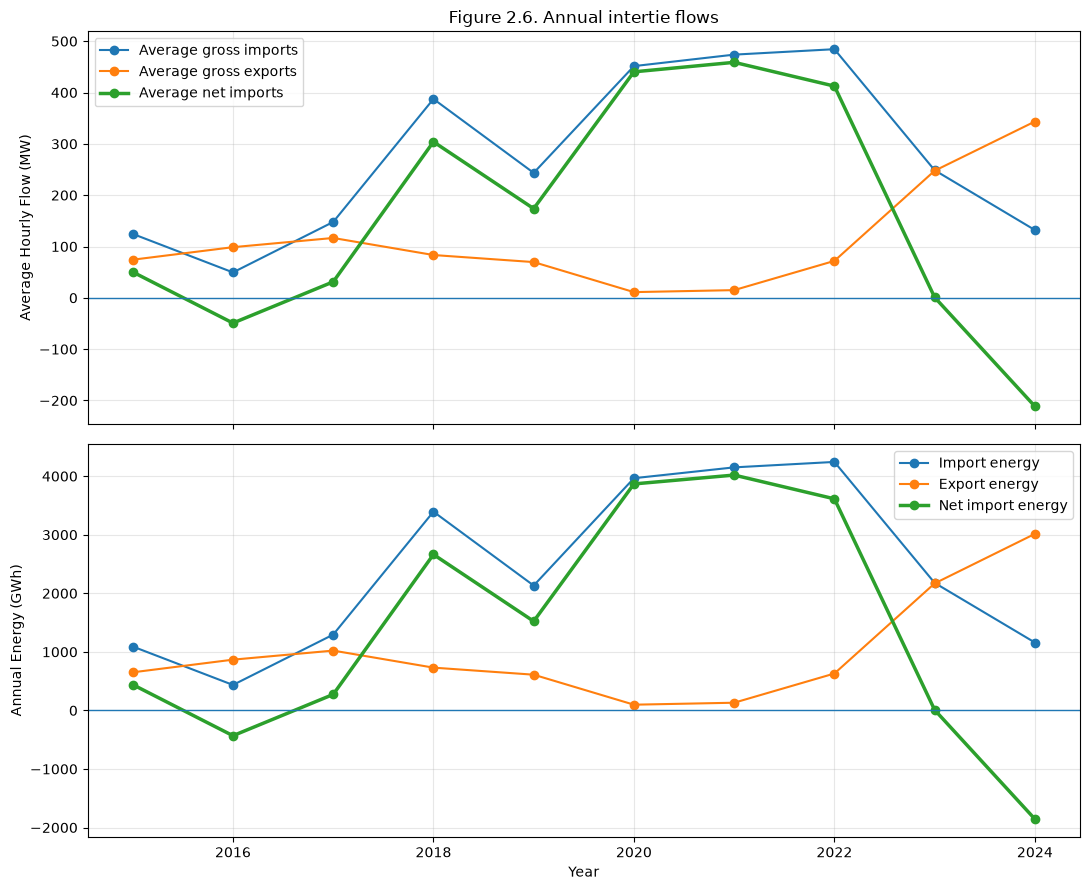

In [21]:
# ---------------------------------------------------------------------
# Visualize annual intertie flows and energy balances
# ---------------------------------------------------------------------

plot_df = annual_interties.copy()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 9),
    sharex=True,
)

# Average hourly power flows.
axes[0].plot(
    plot_df.index,
    plot_df["average_total_imports_mw"],
    marker="o",
    label="Average gross imports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_total_exports_mw"],
    marker="o",
    label="Average gross exports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_net_imports_mw"],
    marker="o",
    linewidth=2.5,
    label="Average net imports",
)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("Figure 2.6. Annual intertie flows")
axes[0].set_ylabel("Average Hourly Flow (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annual imported, exported, and net energy.
axes[1].plot(
    plot_df.index,
    plot_df["total_import_energy_gwh"],
    marker="o",
    label="Import energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["total_export_energy_gwh"],
    marker="o",
    label="Export energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["net_import_energy_gwh"],
    marker="o",
    linewidth=2.5,
    label="Net import energy",
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual Energy (GWh)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------------------
# Summarize imports relative to Alberta Internal Load
# ---------------------------------------------------------------------

imports_share_of_load = (
    master[imports_col]
    / master[load_col]
    * 100
)

annual_import_share = (
    imports_share_of_load
    .groupby(master["year_alberta"])
    .agg(
        average_import_share_pct="mean",
        median_import_share_pct="median",
        p95_import_share_pct=lambda series: series.quantile(0.95),
    )
)

display(annual_import_share.round(2))

,average_import_share_pct,median_import_share_pct,p95_import_share_pct
year_alberta,,,
2015,1.30,0.47,6.27
2016,0.55,0.00,3.13
2017,1.66,0.00,9.18
2018,4.03,3.16,10.24
2019,2.53,1.66,8.86
2020,4.82,4.17,10.72
2021,4.82,4.70,8.53
2022,4.90,5.06,8.73
2023,2.54,2.16,5.81


#### Intertie Flows

Alberta transitioned from broadly balanced electricity trade during 2015–2017 to sustained net imports through 2022, with net-import energy peaking at approximately 4.0 TWh in 2021. Trade was nearly balanced in 2023, and by 2024 Alberta had become a net exporter, recording roughly 1.9 TWh of net-export energy.

Despite this shift in annual net trade, large imports and exports continued throughout the study period. Annual net imports therefore reflect the balance of two-way electricity trade rather than one-way dependence on neighboring jurisdictions. Understanding when Alberta imports or exports—and whether interties become constrained during stressed system conditions—is more informative than annual net totals alone and is examined in later analyses.

### 2.5 Section 2 Summary

In [23]:
# ---------------------------------------------------------------------
# Summarize key structural changes over the study period
# ---------------------------------------------------------------------

first_year = 2015
final_year = 2024

section_2_summary = pd.DataFrame({
    "metric": [
        "Average load",
        "Peak load",
        "Annual electricity consumption",
        "Coal share of total system generation",
        "Wind share of total system generation",
        "Reported maximum generation capacity",
        "Average net imports",
        "Net import energy",
    ],
    f"{first_year}": [
        annual_load.loc[first_year, "average_load_mw"],
        annual_load.loc[first_year, "peak_load_mw"],
        annual_load.loc[first_year, "annual_energy_twh"],
        annual_generation_share.loc[first_year, "Coal"],
        annual_generation_share.loc[first_year, "Wind"],
        annual_capacity_mw.loc[first_year, "Reported Total"],
        annual_interties.loc[first_year, "average_net_imports_mw"],
        annual_interties.loc[first_year, "net_import_energy_gwh"],
    ],
    f"{final_year}": [
        annual_load.loc[final_year, "average_load_mw"],
        annual_load.loc[final_year, "peak_load_mw"],
        annual_load.loc[final_year, "annual_energy_twh"],
        annual_generation_share.loc[final_year, "Coal"],
        annual_generation_share.loc[final_year, "Wind"],
        annual_capacity_mw.loc[final_year, "Reported Total"],
        annual_interties.loc[final_year, "average_net_imports_mw"],
        annual_interties.loc[final_year, "net_import_energy_gwh"],
    ],
    "unit": [
        "MW",
        "MW",
        "TWh",
        "%",
        "%",
        "MW",
        "MW",
        "GWh",
    ],
})

section_2_summary["change"] = (
    section_2_summary[str(final_year)]
    - section_2_summary[str(first_year)]
)

display(
    section_2_summary.style.format({
        "2015": "{:,.2f}",
        "2024": "{:,.2f}",
        "change": "{:+,.2f}",
    })
)

,metric,2015,2024,unit,change
0,Average load,"9,161.75","10,111.42",MW,+949.67
1,Peak load,"11,229.00","12,384.00",MW,"+1,155.00"
2,Annual electricity consumption,80.26,88.75,TWh,+8.49
3,Coal share of total system generation,63.68,2.65,%,-61.03
4,Wind share of total system generation,6.61,19.10,%,+12.49
5,Reported maximum generation capacity,"16,288.00","23,122.00",MW,"+6,834.00"
6,Average net imports,50.30,-211.42,MW,-261.72
7,Net import energy,440.67,"-1,855.61",GWh,"-2,296.28"


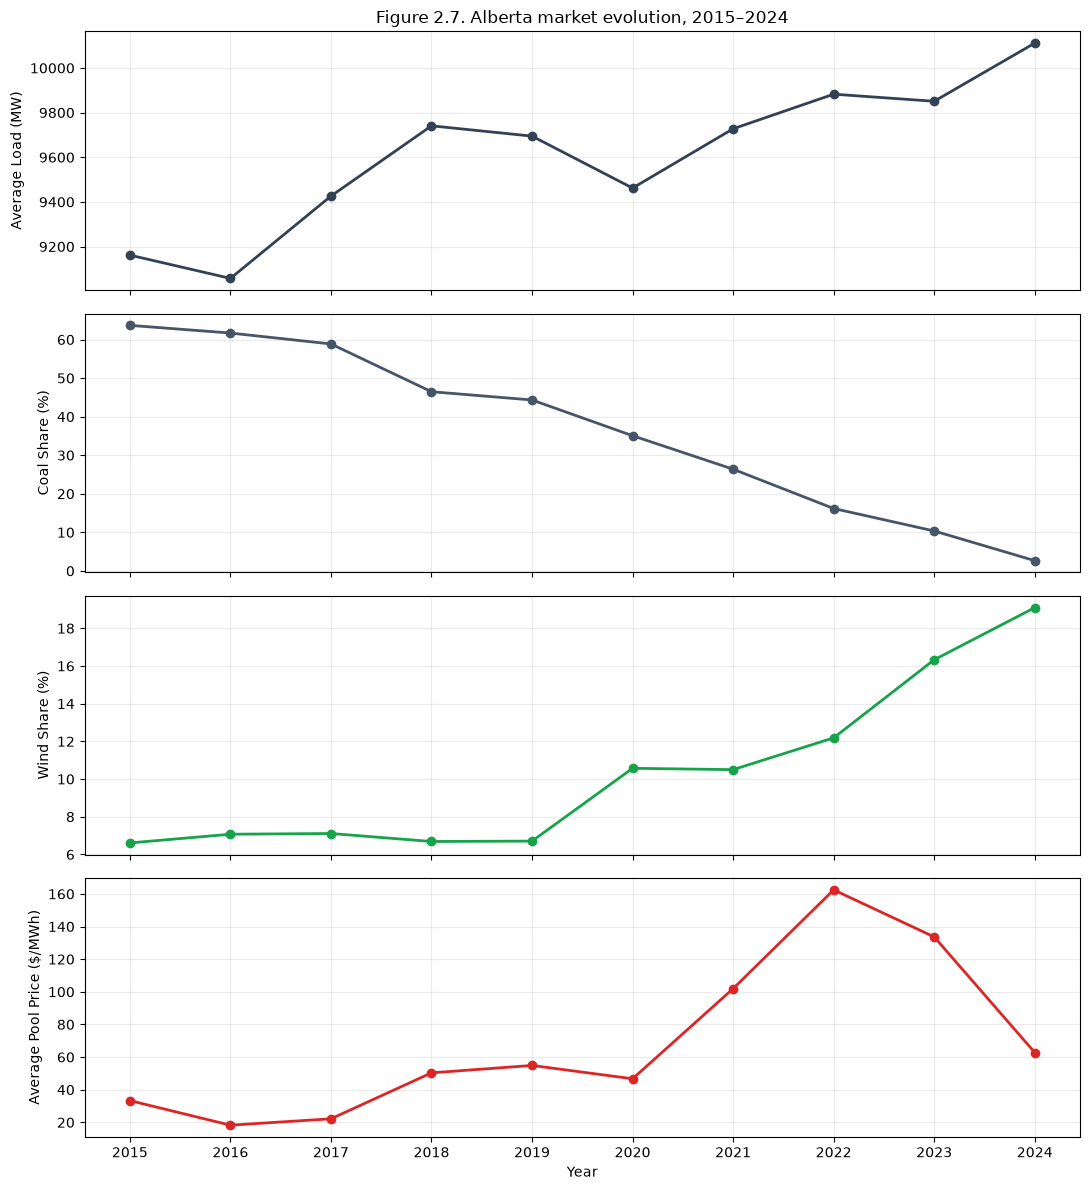

In [24]:
# ---------------------------------------------------------------------
# Summarize Alberta's market evolution in one aligned figure
# ---------------------------------------------------------------------

market_evolution = pd.DataFrame({
    "Average Load (MW)": annual_load["average_load_mw"],
    "Coal Share (%)": annual_generation_share["Coal"],
    "Wind Share (%)": annual_generation_share["Wind"],
    "Average Pool Price ($/MWh)": master.groupby("year_alberta")["pool_price"].mean(),
})

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

colors = ["#334155", "#475569", "#16a34a", "#dc2626"]

for ax, (column, color) in zip(axes, zip(market_evolution.columns, colors)):
    ax.plot(
        market_evolution.index,
        market_evolution[column],
        marker="o",
        linewidth=2,
        color=color,
    )
    ax.set_ylabel(column)
    ax.grid(alpha=0.25)

axes[0].set_title("Figure 2.7. Alberta market evolution, 2015–2024")
axes[-1].set_xlabel("Year")
axes[-1].set_xticks(market_evolution.index)

plt.tight_layout()
plt.show()


#### Section 2 Summary

From 2015 to 2024, Alberta's electricity market underwent substantial structural change. Demand increased, coal generation largely exited, natural-gas technologies became central to dispatchable supply, wind and solar expanded rapidly, reported generation capacity increased, and Alberta transitioned from sustained net imports toward net exports. Together, these changes altered both the composition of supply and the operating conditions under which the market clears.

These structural changes also motivate one of the central concepts used throughout the remainder of the project: net load. Gross load measures electricity demand, whereas net load approximates the demand that must be met by dispatchable generation after variable renewable output is removed. Because wind and solar fluctuate independently of demand, net load provides a more useful representation of system tightness and will serve as a key framework for understanding scarcity and price formation in the analyses that follow.

The next section shifts from long-term structural change to Alberta's recurring hourly operating patterns.

## Section 3 — Normal Operating Patterns

Before focusing on the price tail, we summarize typical daily, weekly, seasonal, renewable, and intertie patterns.

### 3.1 System-Wide Operating Profile


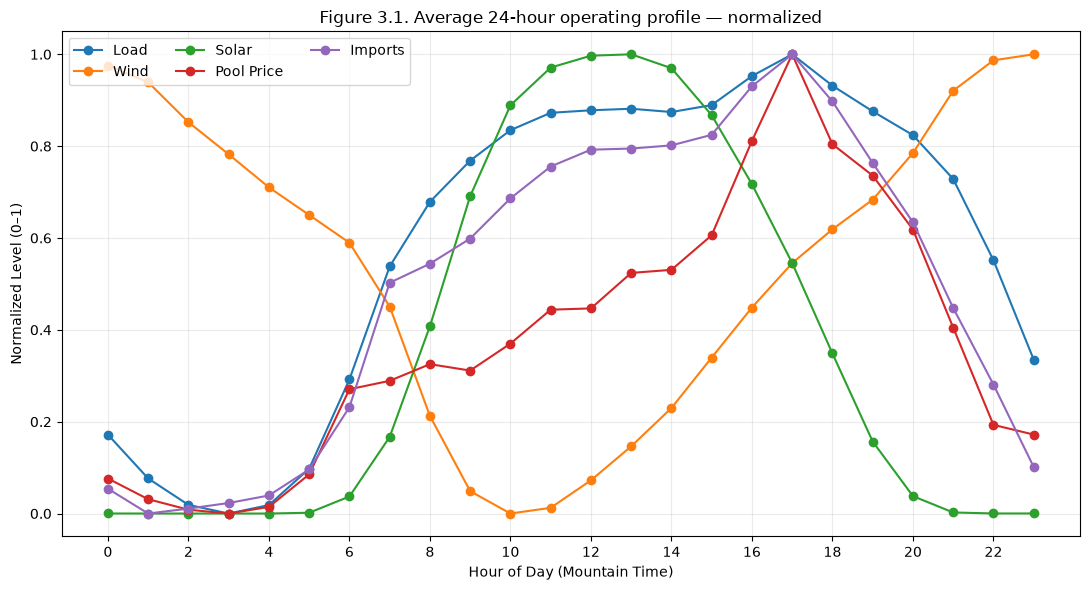

In [25]:
# ---------------------------------------------------------------------
# Compare the average daily shapes of major operating variables
# ---------------------------------------------------------------------

operating_profile_columns = {
    "Load": "ail_mw",
    "Wind": "wind_system_generation",
    "Solar": "solar_system_generation",
    "Pool Price": "pool_price",
    "Imports": "total_imports_mw",
}

average_operating_profile = (
    master.groupby("hour_alberta")[list(operating_profile_columns.values())]
    .mean()
    .rename(columns={value: key for key, value in operating_profile_columns.items()})
)

normalized_operating_profile = (
    (average_operating_profile - average_operating_profile.min())
    / (average_operating_profile.max() - average_operating_profile.min())
)

fig, ax = plt.subplots(figsize=(11, 6))

for column in normalized_operating_profile.columns:
    ax.plot(
        normalized_operating_profile.index,
        normalized_operating_profile[column],
        marker="o",
        label=column,
    )

ax.set_title("Figure 3.1. Average 24-hour operating profile — normalized")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Normalized Level (0–1)")
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=3)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


#### System-Wide Operating Profile

The combined figure illustrates Alberta's daily supply-demand balance: load, imports, and prices rise toward the late-afternoon peak, wind is generally strongest overnight, and solar peaks around midday. Normalization emphasizes timing rather than magnitude, highlighting the mismatch between renewable production and demand. This temporal mismatch motivates net load as a more informative representation of system conditions than gross load alone when examining scarcity and price formation.

### 3.2 Typical Hourly Demand Profile

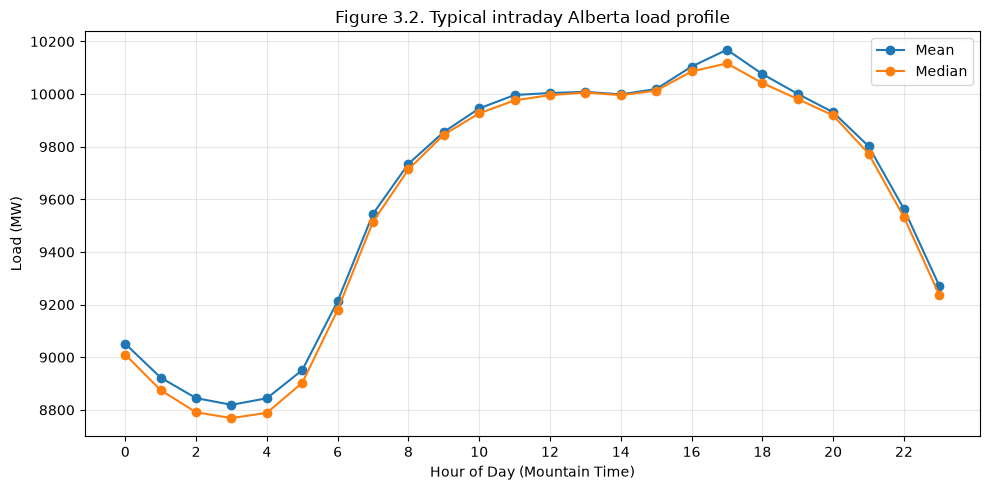

In [26]:
# ---------------------------------------------------------------------
# Summarize the typical hourly Alberta Internal Load profile
# ---------------------------------------------------------------------

hourly_load_profile = (
    master.groupby("hour_alberta")[load_col]
    .agg(["mean", "median"])
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["median"],
    marker="o",
    label="Median",
)

ax.set_title("Figure 3.2. Typical intraday Alberta load profile")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Typical Hourly Demand Profile

Load is lowest around 03:00–04:00, rises through the morning, and peaks near 17:00 before declining through the evening. The close agreement between the mean and median profiles indicates that this intraday pattern is stable despite substantial day-to-day variability.

### 3.3 Weekday Versus Weekend Demand

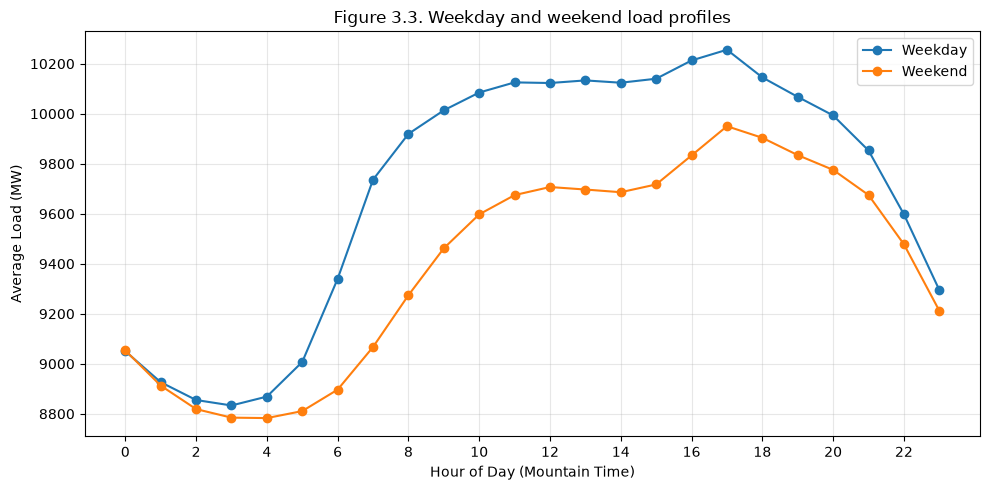

In [27]:
# ---------------------------------------------------------------------
# Compare typical weekday and weekend hourly load profiles
# ---------------------------------------------------------------------

weekday_profile = (
    master.groupby(["hour_alberta", "is_weekend"])[load_col]
    .mean()
    .unstack()
    .rename(
        columns={
            False: "Weekday",
            True: "Weekend",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

for column in weekday_profile.columns:
    ax.plot(
        weekday_profile.index,
        weekday_profile[column],
        marker="o",
        label=column,
    )

ax.set_title("Figure 3.3. Weekday and weekend load profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Weekday and Weekend Demand Profiles

Weekday and weekend demand follow similar daily profiles, but weekday demand is consistently higher between roughly 06:00 and 18:00. This pattern is consistent with greater daytime commercial and industrial activity, although aggregate load data do not directly identify the contributing sectors.

### 3.4 Seasonal Demand Profiles

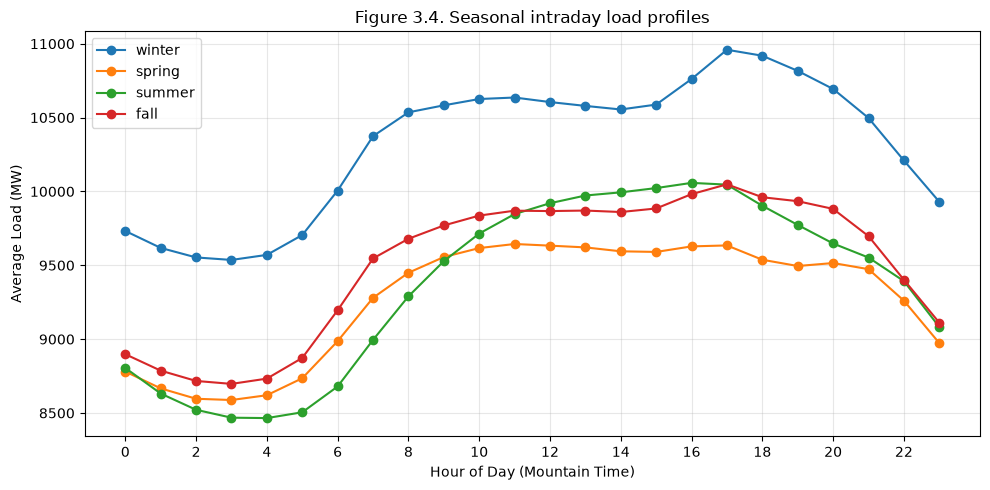

In [28]:
# ---------------------------------------------------------------------
# Compare typical hourly load profiles across seasons
# ---------------------------------------------------------------------

season_order = ["winter", "spring", "summer", "fall"]

seasonal_load_profile = (
    master.groupby(["hour_alberta", "season"])[load_col]
    .mean()
    .unstack()
    .reindex(columns=season_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

for season in seasonal_load_profile.columns:
    ax.plot(
        seasonal_load_profile.index,
        seasonal_load_profile[season],
        marker="o",
        label=season,
    )

ax.set_title("Figure 3.4. Seasonal intraday load profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Seasonal Demand Profiles

Winter records the highest typical loads and spring the lowest. Every season retains the same broad daily structure, with an overnight minimum, morning ramp, and late-afternoon peak. The higher winter demand is consistent with heating requirements and other seasonal patterns of electricity use.

### 3.5 Typical Price and Import Profiles

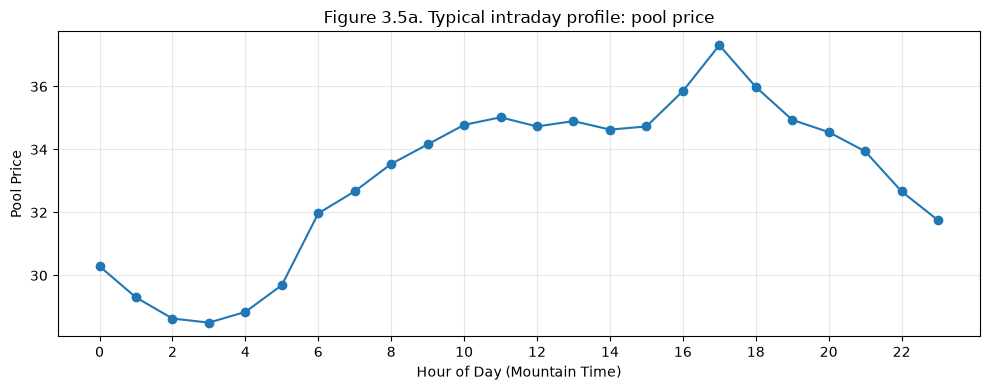

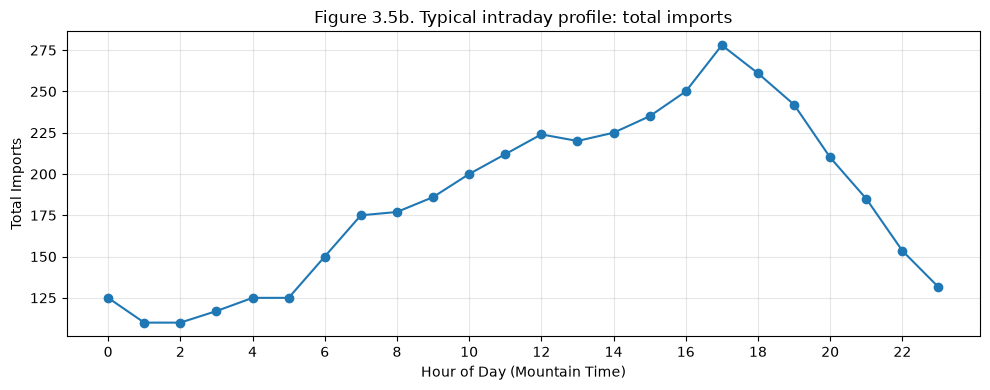

In [29]:
# ---------------------------------------------------------------------
# Compare typical hourly operating profiles for key market variables
# ---------------------------------------------------------------------

profile_variables = {
    "Pool Price": "pool_price",
    "Total Imports": "total_imports_mw",
}

profile_figure_numbers = {
    "Pool Price": "3.5a",
    "Total Imports": "3.5b",
}

for label, column in profile_variables.items():

    profile = (
        master.groupby("hour_alberta")[column]
        .median()
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        profile.index,
        profile.values,
        marker="o",
    )

    ax.set_title(
        f"Figure {profile_figure_numbers[label]}. "
        f"Typical intraday profile: {label.lower()}"
    )
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Typical Price and Import Profiles

Imports and pool prices rise toward the late-afternoon demand peak. Their similar timing does not establish direction: imports may respond to Alberta high-price conditions rather than cause higher prices. Later analyses use lagged intertie flows and transfer-capability utilization to distinguish price response from physical constraint.

### 3.6 Seasonal Solar and Wind Profiles

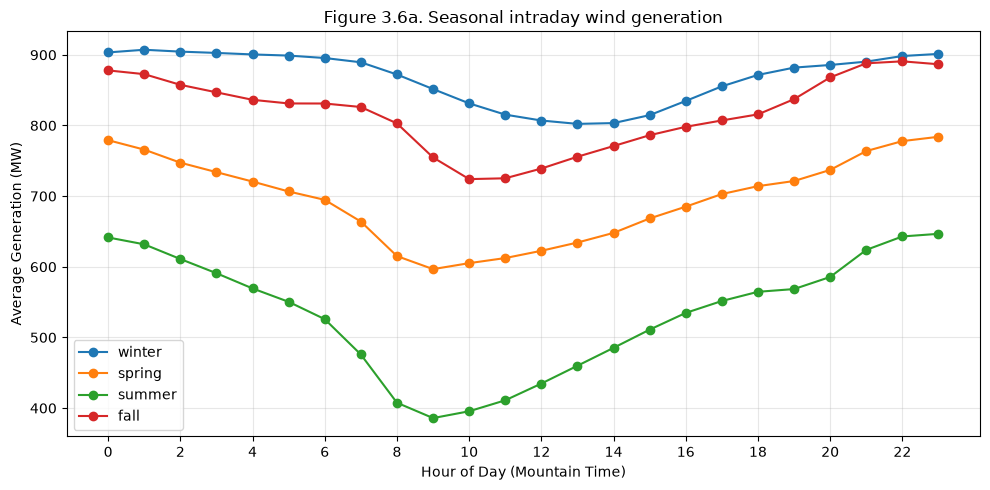

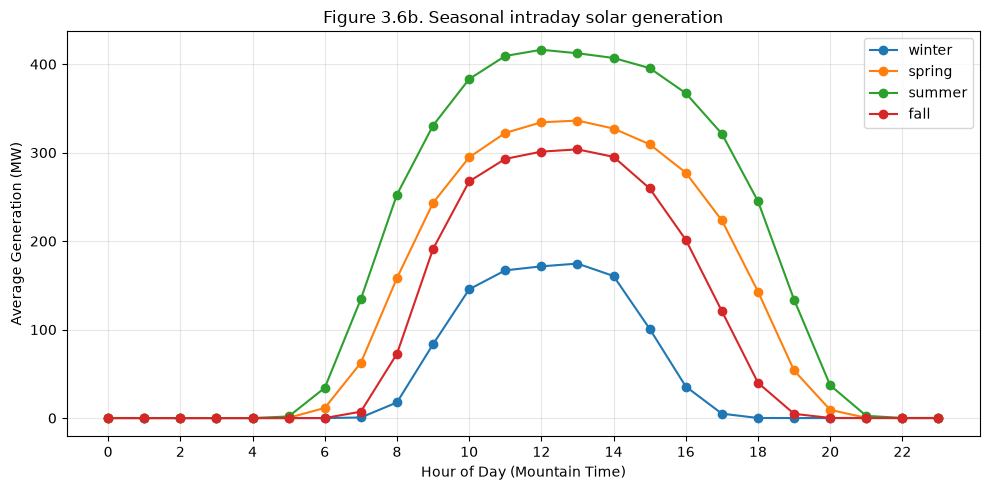

In [30]:
# ---------------------------------------------------------------------
# Compare seasonal hourly wind and solar generation profiles
# ---------------------------------------------------------------------

solar_col = "solar_system_generation"

renewable_profile_variables = {
    "Wind": "wind_system_generation",
    "Solar": solar_col,
}

renewable_figure_numbers = {
    "Wind": "3.6a",
    "Solar": "3.6b",
}

for label, column in renewable_profile_variables.items():

    seasonal_profile = (
        master.groupby(["hour_alberta", "season"])[column]
        .mean()
        .unstack()
        .reindex(columns=season_order)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for season in seasonal_profile.columns:
        ax.plot(
            seasonal_profile.index,
            seasonal_profile[season],
            marker="o",
            label=season,
        )

    ax.set_title(
        f"Figure {renewable_figure_numbers[label]}. "
        f"Seasonal intraday {label.lower()} generation"
    )
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel("Average Generation (MW)")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Seasonal Wind and Solar Generation Profiles

Wind is generally strongest in winter and weakest in summer. Solar peaks around midday and during summer, while Alberta's highest demand typically occurs during winter and the late afternoon. This timing mismatch reinforces the use of net load rather than gross load, while capacity-adjusted output provides a more meaningful comparison as the renewable fleet expands.

## Section 4 — How Variable Is the Market?

The operating profiles define normal conditions, but averages conceal the price tails that matter most for forecasting. This section moves from typical operation to distributions, exceedances, and market regimes.

### 4.1 Distribution Summary

In [31]:
# ---------------------------------------------------------------------
# Summarize the distributions of major market variables
# ---------------------------------------------------------------------

distribution_columns = {
    "Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

distribution_summary = pd.DataFrame({
    label: master[column].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    for label, column in distribution_columns.items()
}).T

distribution_summary.columns = [
    "p01",
    "p05",
    "p25",
    "median",
    "p75",
    "p95",
    "p99",
]

display(distribution_summary.round(3))

,p01,p05,p25,median,p75,p95,p99
Load,7740.000,8199.000,9024.000,9616.000,10226.000,10979.000,11402.000
Pool Price,4.596,13.620,21.350,33.230,55.100,259.960,781.125
AECO Gas,0.000,0.500,1.700,2.350,2.770,5.300,7.050
Spark Spread,-8.295,-3.285,6.395,18.715,33.915,233.727,758.258
Net Imports,-920.000,-561.000,-50.000,125.000,450.000,835.000,951.000
Total Imports,0.000,0.000,30.000,180.000,460.000,845.000,953.000
Total Exports,0.000,0.000,0.000,0.000,125.000,635.000,960.000
Total Outages,2147.300,2397.300,2981.400,3440.300,3921.300,4744.400,5636.240


#### Distribution Summary

Load and outages occupy comparatively narrow physical ranges. Pool price and spark spread are strongly right-skewed, with infrequent extreme values far exceeding typical conditions. Intertie flows are asymmetric and span both importing and exporting conditions.

These distributions motivate quantile, regime, and event-based analyses rather than reliance on averages alone, because many of Alberta's most operationally significant market events occur in the tails of the distributions.

### 4.2 Histograms

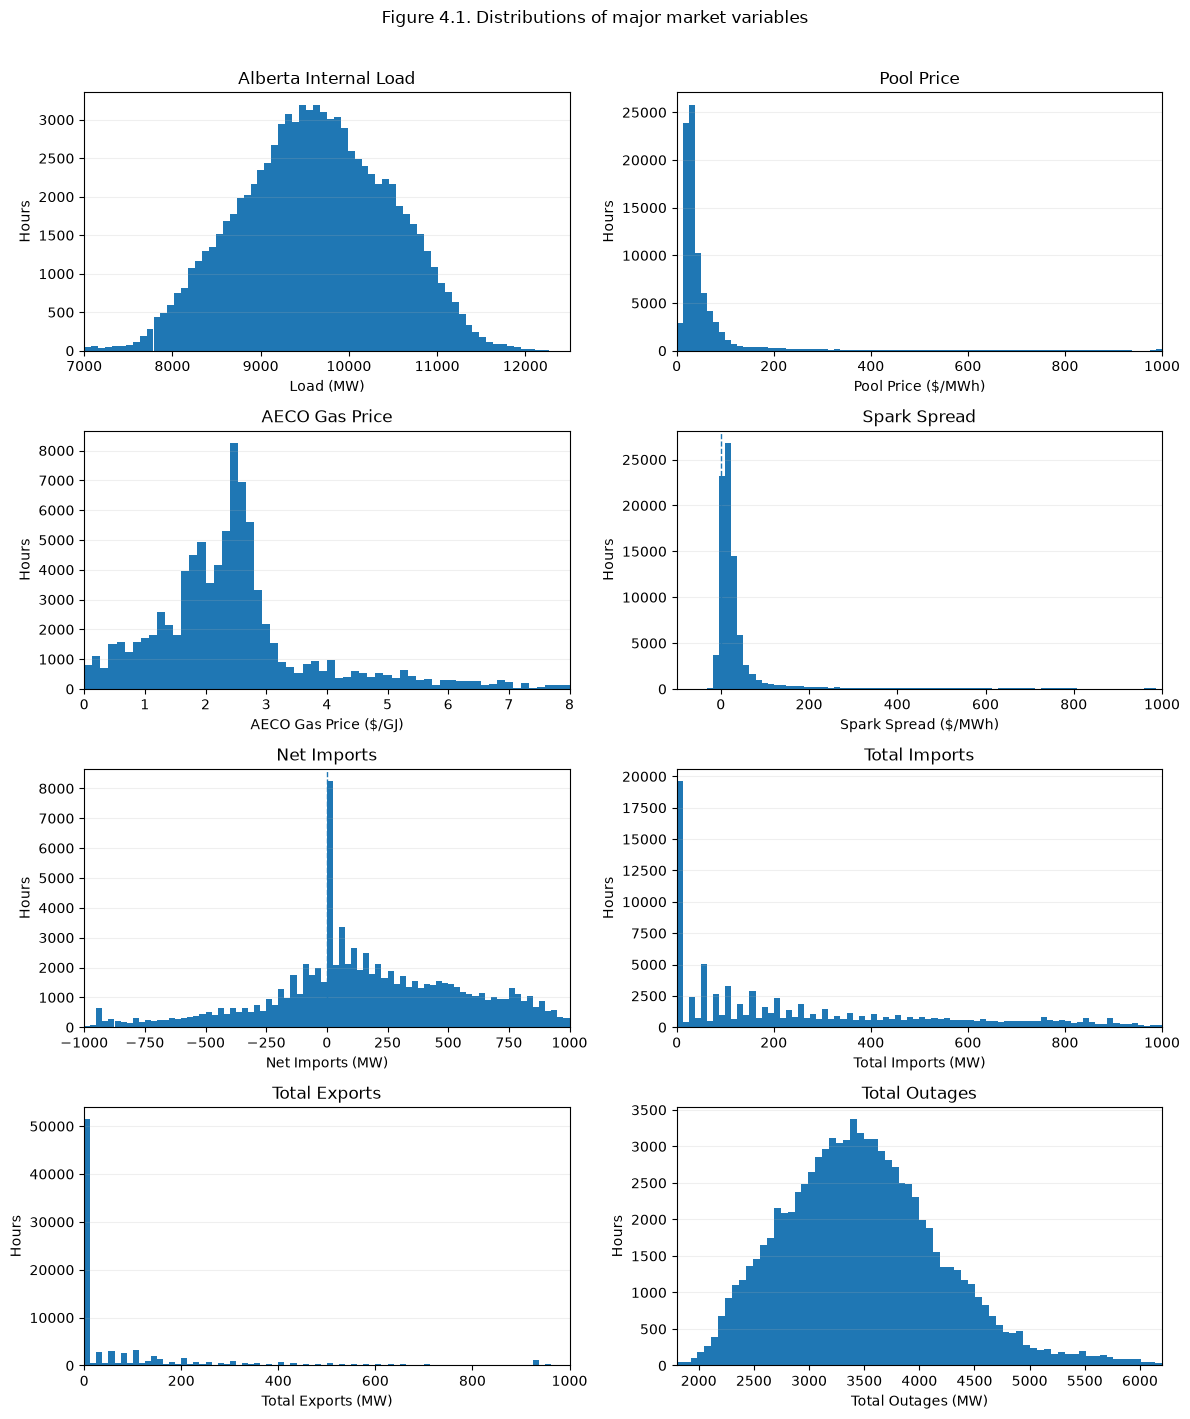

In [32]:
# ---------------------------------------------------------------------
# Visualize major market-variable distributions in a compact panel
# ---------------------------------------------------------------------

histogram_variables = {
    "Alberta Internal Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas Price": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

# Display ranges emphasize the main body of each distribution.
# Observations outside these ranges remain represented in the
# quantile, exceedance, and price-duration summaries.
display_limits = {
    "Alberta Internal Load": (7000, 12500),
    "Pool Price": (0, 1000),
    "AECO Gas Price": (0, 8),
    "Spark Spread": (-100, 1000),
    "Net Imports": (-1000, 1000),
    "Total Imports": (0, 1000),
    "Total Exports": (0, 1000),
    "Total Outages": (1800, 6200),
}

# Domain-specific bin counts chosen to balance detail and readability.
histogram_bins = {
    "Alberta Internal Load": 70,
    "Pool Price": 80,
    "AECO Gas Price": 60,
    "Spark Spread": 80,
    "Net Imports": 80,
    "Total Imports": 80,
    "Total Exports": 80,
    "Total Outages": 70,
}

axis_labels = {
    "Alberta Internal Load": "Load (MW)",
    "Pool Price": "Pool Price ($/MWh)",
    "AECO Gas Price": "AECO Gas Price ($/GJ)",
    "Spark Spread": "Spark Spread ($/MWh)",
    "Net Imports": "Net Imports (MW)",
    "Total Imports": "Total Imports (MW)",
    "Total Exports": "Total Exports (MW)",
    "Total Outages": "Total Outages (MW)",
}

signed_variables = {
    "Spark Spread",
    "Net Imports",
}

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 14),
)

fig.suptitle(
    "Figure 4.1. Distributions of major market variables",
    y=1.01,
)

for ax, (title, column) in zip(
    axes.flat,
    histogram_variables.items(),
):
    lower_limit, upper_limit = display_limits[title]

    # Restrict the displayed sample before calculating bin edges.
    # This prevents extreme observations outside the plotted domain
    # from compressing the visible distribution into a few bins.
    displayed_values = (
        master.loc[
            master[column].between(
                lower_limit,
                upper_limit,
                inclusive="both",
            ),
            column,
        ]
        .dropna()
    )

    bin_edges = np.linspace(
        lower_limit,
        upper_limit,
        histogram_bins[title] + 1,
    )

    ax.hist(
        displayed_values,
        bins=bin_edges,
    )

    if title in signed_variables:
        ax.axvline(
            0,
            linewidth=1,
            linestyle="--",
        )

    ax.set_xlim(lower_limit, upper_limit)
    ax.set_title(title)
    ax.set_xlabel(axis_labels[title])
    ax.set_ylabel("Hours")
    ax.grid(
        axis="y",
        alpha=0.2,
    )

plt.tight_layout()
plt.show()

#### Distribution Characteristics

Load and outages are comparatively concentrated, while pool price and spark spread exhibit long right tails. Gas prices are moderately skewed, and intertie flows are asymmetric: imports and especially exports are concentrated at lower values with occasional large flows.

The contrast between relatively stable physical quantities and highly volatile economic outcomes motivates threshold, quantile, and regime-based analysis. In particular, later sections test whether gas prices become materially more informative only when gas prices or system tightness are already elevated.

> Display ranges emphasize the main body of each distribution; extreme values remain represented in the quantile, exceedance, and price-duration summaries.

### 4.3 Price Exceedance Frequency

In [33]:
# ---------------------------------------------------------------------
# Summarize pool-price exceedance frequencies
# ---------------------------------------------------------------------

price_thresholds = [0, 100, 200, 500, 900]

price_exceedance = pd.DataFrame({
    "threshold": price_thresholds,
    "hours_at_or_above": [
        master["pool_price"].ge(threshold).sum()
        for threshold in price_thresholds
    ],
    "share_of_hours_pct": [
        master["pool_price"].ge(threshold).mean() * 100
        for threshold in price_thresholds
    ],
})

display(price_exceedance.round(3))


,threshold,hours_at_or_above,share_of_hours_pct
0,0,87665,100.000
1,100,9605,10.956
2,200,5411,6.172
3,500,2292,2.614
4,900,378,0.431


In [34]:
# ---------------------------------------------------------------------
# Summarize annual pool-price regimes without modifying master
# ---------------------------------------------------------------------

price_col = "pool_price"

price_regime_flags = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    price_col: master[price_col],
    "above_100": master[price_col].ge(100),
    "above_200": master[price_col].ge(200),
    "above_500": master[price_col].ge(500),
    "at_or_above_900": master[price_col].ge(900),
    "negative_price": master[price_col].lt(0),
})

annual_price_extremes = (
    price_regime_flags
    .groupby("year_alberta")
    .agg(
        average_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        price_volatility=(price_col, "std"),
        hours_above_100=("above_100", "sum"),
        hours_above_200=("above_200", "sum"),
        hours_above_500=("above_500", "sum"),
        hours_at_or_above_900=("at_or_above_900", "sum"),
        negative_price_hours=("negative_price", "sum"),
    )
)

display(annual_price_extremes.round(2))


,average_price,median_price,price_volatility,hours_above_100,hours_above_200,hours_above_500,hours_at_or_above_900,negative_price_hours
year_alberta,,,,,,,,
2015,33.34,20.48,86.51,196,144,95,28,0
2016,18.28,15.46,12.63,8,4,2,0,0
2017,22.19,19.46,26.96,26,17,6,4,0
2018,50.35,33.25,87.22,361,208,102,29,0
2019,54.88,33.51,90.39,442,264,116,17,0
2020,46.72,33.28,92.13,306,189,102,40,0
2021,101.93,57.34,138.96,1651,871,310,42,0
2022,162.46,83.78,199.22,3179,1663,758,111,0
2023,133.63,57.20,183.84,2446,1547,606,52,0


#### Price Distribution and High-Price Hours

Prices exceeded \$500/MWh during approximately 2.6% of hours. Hours at or above \$900/MWh were rare, accounting for roughly 0.4% of observations.

Annual statistics reveal several market regimes. Prices and high-price-hour frequencies were especially low during 2016–2017, increased during 2018–2020, entered a sustained high-price regime during 2021–2023, and moderated in 2024. Average pool price peaked at approximately \$162/MWh in 2022.

Despite substantial renewable additions and a larger reported generation fleet, prices became materially higher over this period. The descriptive results alone cannot explain why. Candidate drivers include fuel costs, generation availability, outages, net load, market design, and their interactions. Identifying the dominant mechanisms is a central objective of the analyses that follow.

### 4.4 Annual Price-Duration Curves

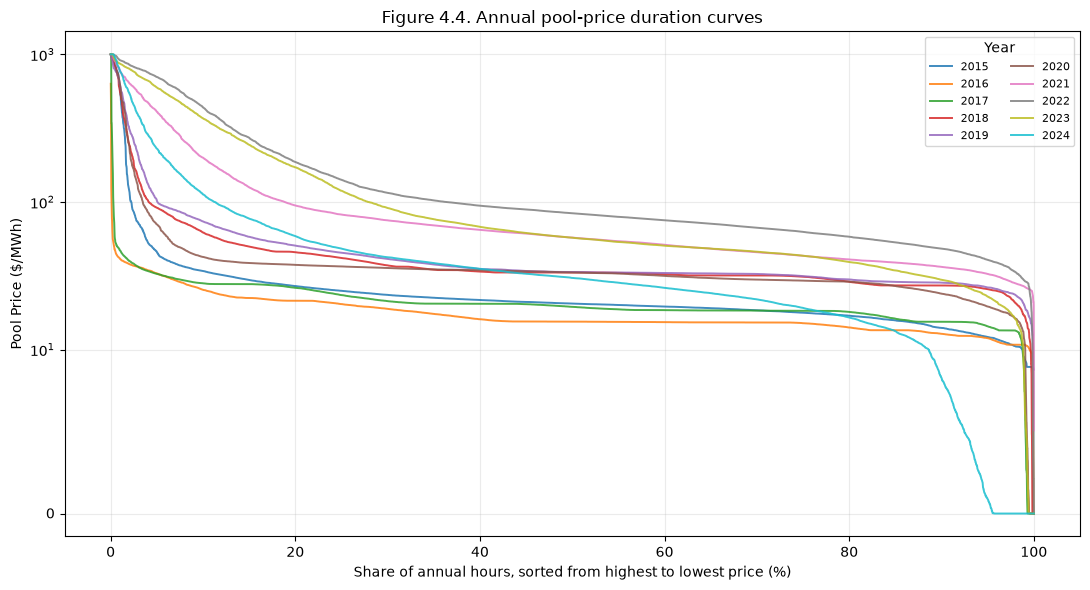

In [35]:
# ---------------------------------------------------------------------
# Plot annual price-duration curves
# ---------------------------------------------------------------------

price_duration = master[["year_alberta", price_col]].dropna().copy()

fig, ax = plt.subplots(figsize=(11, 6))

for year, group in price_duration.groupby("year_alberta"):
    sorted_prices = (
        group[price_col]
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    exceedance_rank_pct = (
        (np.arange(len(sorted_prices)) + 1)
        / len(sorted_prices)
        * 100
    )

    ax.plot(
        exceedance_rank_pct,
        sorted_prices,
        linewidth=1.4,
        alpha=0.85,
        label=int(year),
    )

ax.set_title("Figure 4.4. Annual pool-price duration curves")
ax.set_xlabel("Share of annual hours, sorted from highest to lowest price (%)")
ax.set_ylabel("Pool Price ($/MWh)")
ax.set_yscale("symlog", linthresh=10)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, title="Year")

plt.tight_layout()
plt.show()


#### Annual Price-Duration Curves

Price-duration curves make the tail behaviour visible by sorting each year's hourly prices from highest to lowest. The relatively quiet 2016–2017 period exhibits a short upper tail, whereas 2021–2023 display both higher and substantially broader tails, reflecting more frequent and more severe price spikes.

Price-duration curves are a standard tool in electricity-market analysis because they distinguish the large number of ordinary operating hours from the relatively few high-price hours that drive volatility, scarcity, and many trading outcomes.

## Section 5 — When Do High-Price Hours Occur?

Having defined the relevant price tail, we now identify when high-price hours occur by year, month, hour, and event duration.

### 5.1 High-Price Hour Definition and Base Rate


In [36]:
# ---------------------------------------------------------------------
# Confirm the high-price definition and overall hourly frequency
# ---------------------------------------------------------------------

high_price_event = master[price_col].ge(200).rename("high_price_event")

high_price_summary = pd.Series({
    "total_hours": len(master),
    "high_price_hours": high_price_event.sum(),
    "high_price_rate_pct": high_price_event.mean() * 100,
})

display(high_price_summary.round(2))


total_hours            87665.00
high_price_hours        5411.00
high_price_rate_pct        6.17
dtype: float64

In [37]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar year
# ---------------------------------------------------------------------

high_price_by_year = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("year_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
)

high_price_by_year["high_price_rate_pct"] = high_price_by_year["high_price_rate"] * 100

display(high_price_by_year.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
year_alberta,,,,,
2015,8760,144,0.016,33.338,1.644
2016,8784,4,0.000,18.279,0.046
2017,8760,17,0.002,22.186,0.194
2018,8760,208,0.024,50.348,2.374
2019,8760,264,0.030,54.880,3.014
2020,8784,189,0.022,46.716,2.152
2021,8760,871,0.099,101.932,9.943
2022,8760,1663,0.190,162.463,18.984
2023,8760,1547,0.177,133.628,17.660


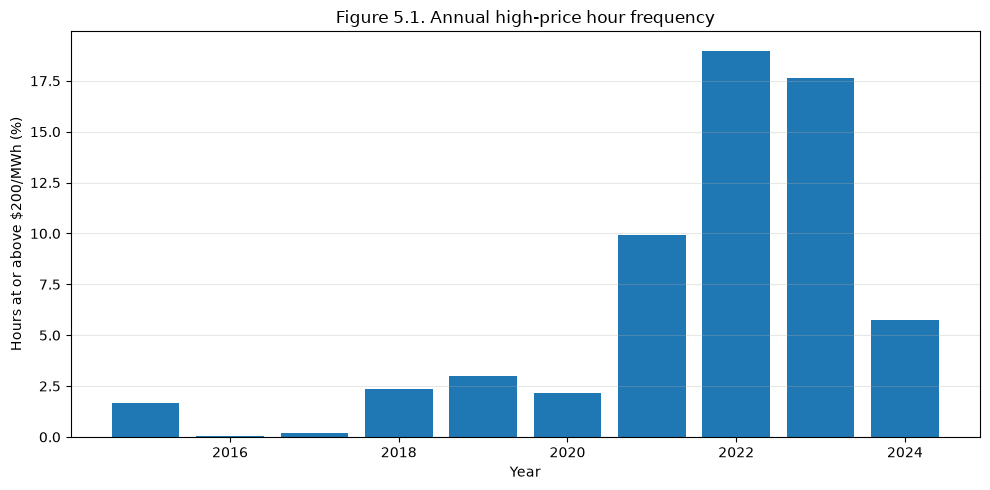

In [38]:
# ---------------------------------------------------------------------
# Visualize annual high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_year.index,
    high_price_by_year["high_price_rate_pct"],
)

ax.set_title("Figure 5.1. Annual high-price hour frequency")
ax.set_xlabel("Year")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

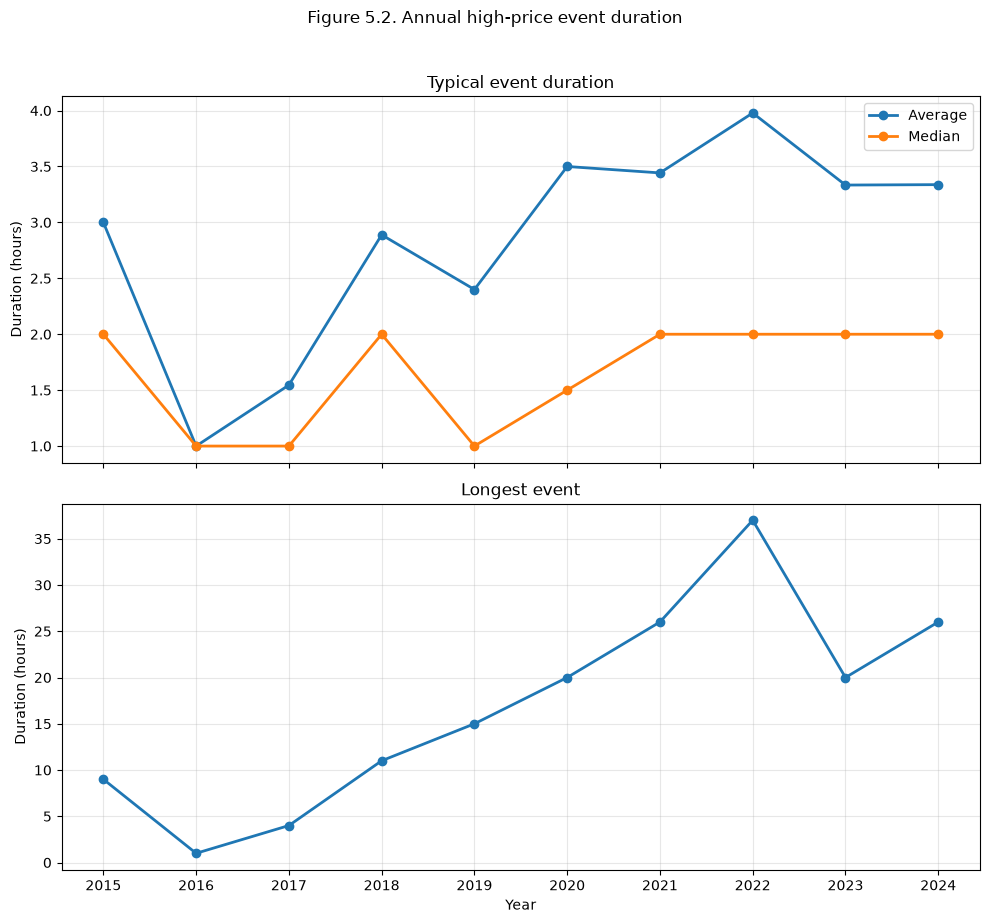

In [39]:
# ---------------------------------------------------------------------
# Visualize annual high-price event duration
# ---------------------------------------------------------------------

# Build consecutive high-price events
high_price_events = (
    pd.DataFrame({
        "timestamp_utc": master["timestamp_utc"],
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event.astype(bool),
    })
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

run_id = (
    high_price_events["high_price_event"]
    .ne(high_price_events["high_price_event"].shift(fill_value=False))
    .cumsum()
)

high_price_runs = (
    high_price_events.loc[high_price_events["high_price_event"]]
    .assign(run_id=run_id[high_price_events["high_price_event"]].to_numpy())
    .groupby("run_id")
    .agg(
        start_utc=("timestamp_utc", "min"),
        end_utc=("timestamp_utc", "max"),
        start_year_alberta=("year_alberta", "first"),
        duration_hours=("timestamp_utc", "size"),
    )
    .reset_index(drop=True)
)

annual_event_duration = (
    high_price_runs
    .groupby("start_year_alberta")
    .agg(
        average_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        maximum_duration_hours=("duration_hours", "max"),
    )
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

fig.suptitle(
    "Figure 5.2. Annual high-price event duration",
    y=1.02,
)

# ---------------------------------------------------------------------
# Average and median duration
# ---------------------------------------------------------------------

axes[0].plot(
    annual_event_duration.index,
    annual_event_duration["average_duration_hours"],
    marker="o",
    linewidth=2,
    label="Average",
)

axes[0].plot(
    annual_event_duration.index,
    annual_event_duration["median_duration_hours"],
    marker="o",
    linewidth=2,
    label="Median",
)

axes[0].set_title("Typical event duration")
axes[0].set_ylabel("Duration (hours)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---------------------------------------------------------------------
# Maximum duration
# ---------------------------------------------------------------------

axes[1].plot(
    annual_event_duration.index,
    annual_event_duration["maximum_duration_hours"],
    marker="o",
    linewidth=2,
)

axes[1].set_title("Longest event")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Duration (hours)")
axes[1].set_xticks(annual_event_duration.index)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Hour Definition and Base Rate

An hour is labelled high price when the pool price is at least \$200/MWh. This threshold defines an hourly price state, not a direct observation of reserve deficiency, physical shortage, or involuntary curtailment. Across the study period, 5,411 of 87,665 observed hours (6.2%) met this criterion.

High-price hours were uncommon before 2021, increased sharply during 2021–2023, and moderated in 2024. The 2024 rate is based on 8,777 observed hours.

High-price events also became more persistent during the later market regime. The typical event remained relatively short, with the median duration increasing from roughly one hour before 2021 to about two hours thereafter. However, the mean duration increased more substantially and the longest annual events expanded from only one or two consecutive hours during the quietest years to 37 hours in 2022. Together, these results indicate that the 2021–2023 regime was characterized not only by more frequent high-price hours but also by a greater likelihood of prolonged periods of sustained price stress.

### 5.2 Consecutive High-Price Event Duration


In [40]:
# ---------------------------------------------------------------------
# Summarize persistence of consecutive high-price events
# ---------------------------------------------------------------------

high_price_events = (
    pd.DataFrame({
        "timestamp_utc": master["timestamp_utc"],
        "year_alberta": master["year_alberta"],
        "high_price_event": high_price_event.astype(bool),
    })
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

run_id = high_price_events["high_price_event"].ne(
    high_price_events["high_price_event"].shift(fill_value=False)
).cumsum()

high_price_runs["duration_bucket"] = pd.cut(
    high_price_runs["duration_hours"],
    bins=[0, 1, 2, 5, np.inf],
    labels=["1 hour", "2 hours", "3-5 hours", "6+ hours"],
    right=True,
)

event_duration_summary = (
    high_price_runs
    .groupby("duration_bucket", observed=False)
    .agg(
        event_count=("duration_hours", "size"),
        high_price_hours=("duration_hours", "sum"),
        median_duration_hours=("duration_hours", "median"),
        max_duration_hours=("duration_hours", "max"),
    )
)

event_duration_summary["share_of_events_pct"] = (
    event_duration_summary["event_count"]
    / event_duration_summary["event_count"].sum()
    * 100
)

display(event_duration_summary.round(2))

display(
    high_price_runs
    .sort_values("duration_hours", ascending=False)
    .head(10)
)


,event_count,high_price_hours,median_duration_hours,max_duration_hours,share_of_events_pct
duration_bucket,,,,,
1 hour,629,629,1.0,1,39.68
2 hours,288,576,2.0,2,18.17
3-5 hours,371,1374,4.0,5,23.41
6+ hours,297,2832,8.0,37,18.74


,start_utc,end_utc,start_year_alberta,duration_hours,duration_bucket
948,2022-12-19 19:00:00+00:00,2022-12-21 07:00:00+00:00,2022,37,6+ hours
882,2022-11-08 18:00:00+00:00,2022-11-10 06:00:00+00:00,2022,37,6+ hours
930,2022-12-12 06:00:00+00:00,2022-12-13 08:00:00+00:00,2022,27,6+ hours
1443,2024-01-13 06:00:00+00:00,2024-01-14 07:00:00+00:00,2024,26,6+ hours
543,2021-12-27 13:00:00+00:00,2021-12-28 14:00:00+00:00,2021,26,6+ hours
801,2022-09-14 05:00:00+00:00,2022-09-15 05:00:00+00:00,2022,25,6+ hours
1444,2024-01-14 09:00:00+00:00,2024-01-15 06:00:00+00:00,2024,22,6+ hours
1442,2024-01-12 07:00:00+00:00,2024-01-13 04:00:00+00:00,2024,22,6+ hours
1315,2023-08-22 12:00:00+00:00,2023-08-23 07:00:00+00:00,2023,20,6+ hours
250,2020-01-15 11:00:00+00:00,2020-01-16 06:00:00+00:00,2020,20,6+ hours


#### Consecutive High-Price Event Duration

High-price hours are not only isolated hourly observations. Grouping consecutive high-price hours into events shows whether price stress appears as brief spikes or persistent operating conditions. Approximately 40% of events consist of a single high-price hour, while roughly 19% persist for six hours or longer; the longest observed events last 37 consecutive hours.

This distinction matters because market participants experience prolonged periods of price stress differently from isolated spikes, and forecasting models should be evaluated on both event occurrence and event persistence.

### 5.3 High-Price Hours by Month


In [41]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by calendar month
# ---------------------------------------------------------------------

month_order = [
    "january", "february", "march", "april",
    "may", "june", "july", "august",
    "september", "october", "november", "december",
]

high_price_by_month = (
    pd.DataFrame({
        "month_name_alberta": master["month_name_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("month_name_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
    )
    .reindex(month_order)
)

high_price_by_month["high_price_rate_pct"] = high_price_by_month["high_price_rate"] * 100

display(high_price_by_month.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,high_price_rate_pct
month_name_alberta,,,,,
january,7440,445,0.060,72.209,5.981
february,6792,436,0.064,70.791,6.419
march,7430,344,0.046,57.597,4.630
april,7200,341,0.047,57.961,4.736
may,7440,432,0.058,65.150,5.806
june,7200,539,0.075,76.716,7.486
july,7440,564,0.076,73.116,7.581
august,7440,585,0.079,79.289,7.863
september,7200,464,0.064,70.265,6.444


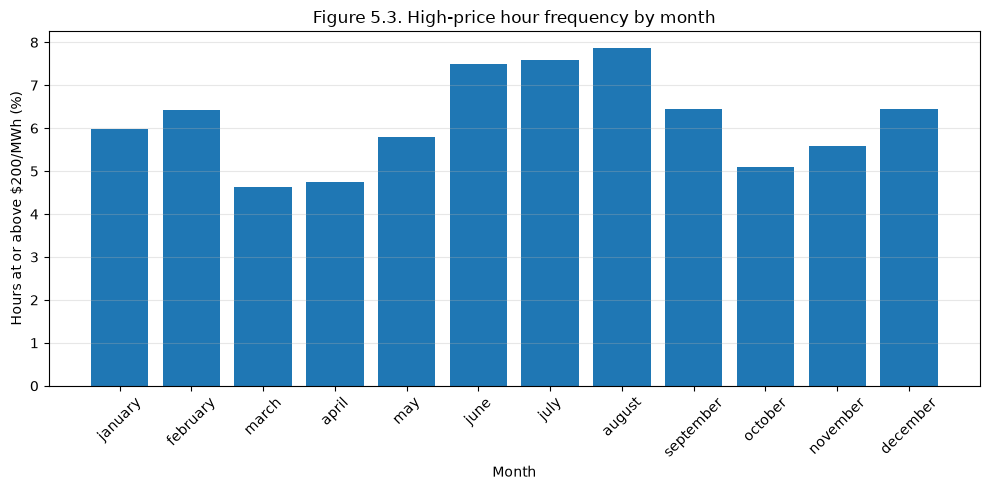

In [42]:
# ---------------------------------------------------------------------
# Visualize seasonal patterns in high-price frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    high_price_by_month.index,
    high_price_by_month["high_price_rate_pct"],
)

ax.set_title("Figure 5.3. High-price hour frequency by month")
ax.set_xlabel("Month")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### High-Price Hours by Month

Pooling all years, high-price hours occur most frequently during summer and are also elevated during winter. However, the year–month heatmap shows that this seasonal pattern is partly influenced by the concentration of the 2021–2023 high-price regime.

Later analyses test whether month remains predictive after controlling for market regime and whether summer and winter high-price hours arise from different combinations of temperature, load, outages, renewable generation, and intertie conditions.

### 5.4 High-Price Hours by Hour

In [43]:
# ---------------------------------------------------------------------
# Summarize high-price frequency by hour of day
# ---------------------------------------------------------------------

high_price_by_hour = (
    pd.DataFrame({
        "hour_alberta": master["hour_alberta"],
        "high_price_event": high_price_event,
        "pool_price": master[price_col],
    })
    .groupby("hour_alberta")
    .agg(
        observed_hours=("high_price_event", "size"),
        high_price_hours=("high_price_event", "sum"),
        high_price_rate=("high_price_event", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
    )
)

high_price_by_hour["high_price_rate_pct"] = high_price_by_hour["high_price_rate"] * 100

display(high_price_by_hour.round(3))


,observed_hours,high_price_hours,high_price_rate,average_price,median_price,high_price_rate_pct
hour_alberta,,,,,,
0,3653,79,0.022,43.782,30.290,2.163
1,3663,56,0.015,40.070,29.300,1.529
2,3643,41,0.011,38.187,28.630,1.125
3,3653,32,0.009,37.500,28.500,0.876
4,3653,51,0.014,38.694,28.840,1.396
5,3653,89,0.024,44.520,29.690,2.436
6,3653,193,0.053,59.793,31.970,5.283
7,3653,185,0.051,61.305,32.670,5.064
8,3653,199,0.054,64.292,33.540,5.448


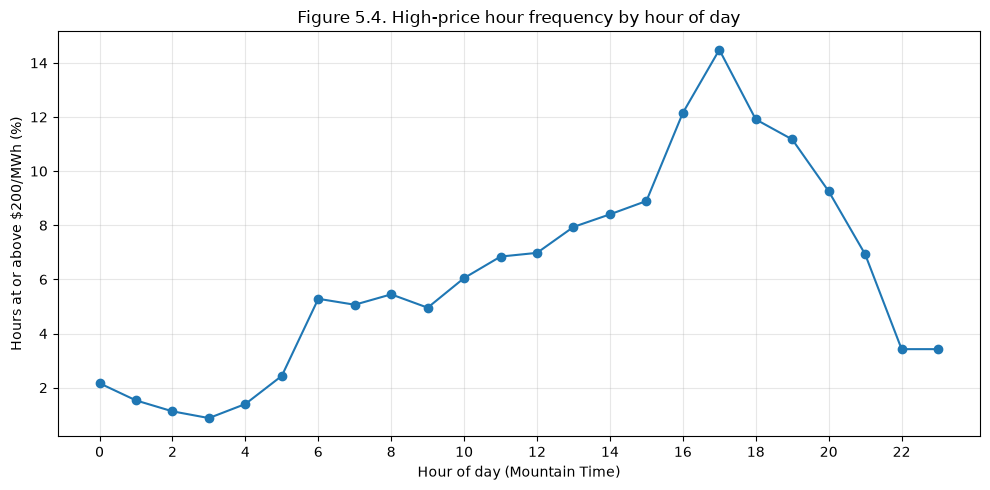

In [44]:
# ---------------------------------------------------------------------
# Visualize the intraday distribution of high-price hours
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    high_price_by_hour.index,
    high_price_by_hour["high_price_rate_pct"],
    marker="o",
)

ax.set_title("Figure 5.4. High-price hour frequency by hour of day")
ax.set_xlabel("Hour of day (Mountain Time)")
ax.set_ylabel("Hours at or above $200/MWh (%)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### High-Price Hours by Hour

The high-price-hour rate is lowest overnight, rises through the day, and peaks near 17:00 alongside the late-afternoon demand peak. Its intraday profile closely mirrors that of average pool price, although this similarity alone does not establish which underlying system conditions drive either pattern.

Later analyses test whether net load and available system margin explain high-price hours better than gross load alone.

### 5.5 Year-Month High-Price Hour Map

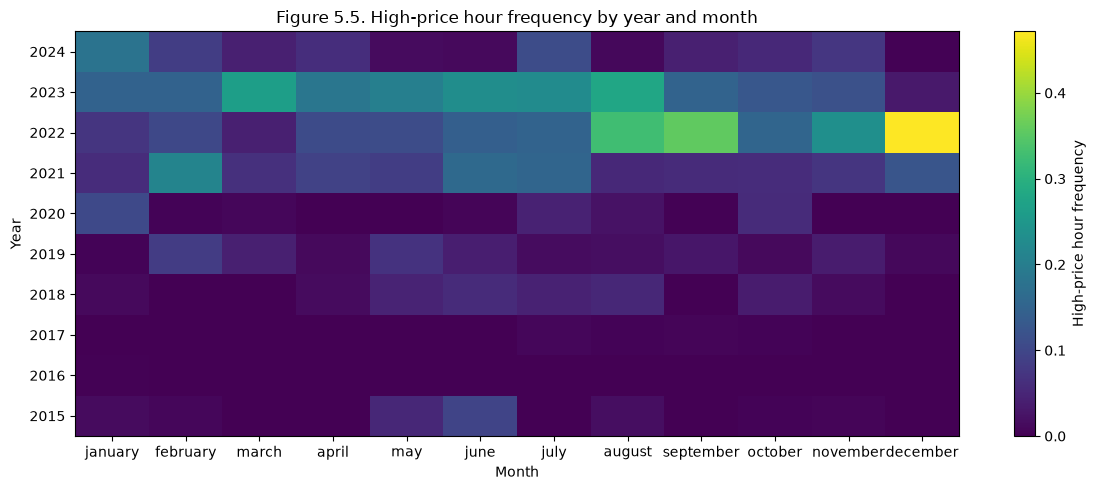

In [45]:
# ---------------------------------------------------------------------
# Visualize the monthly evolution of high-price frequency
# ---------------------------------------------------------------------

high_price_calendar = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "month_alberta": master["month_alberta"],
        "high_price_event": high_price_event,
    })
    .groupby(["year_alberta", "month_alberta"])["high_price_event"]
    .mean()
    .unstack()
    .reindex(columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(high_price_calendar, aspect="auto", origin="lower")
ax.set_title("Figure 5.5. High-price hour frequency by year and month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticks(range(12))
ax.set_xticklabels(month_order)
ax.set_yticks(range(len(high_price_calendar.index)))
ax.set_yticklabels(high_price_calendar.index)
plt.colorbar(image, ax=ax, label="High-price hour frequency")

plt.tight_layout()
plt.show()


#### Monthly Evolution of High-Price Hours

The heatmap reveals persistent market regimes rather than isolated high-price months. High-price months were sporadic before 2021, became sustained throughout 2021–2023, and moderated during 2024. December 2022 was the most severe month, with nearly half of all hours priced at or above \$200/MWh.

The persistence of elevated prices across consecutive months suggests common regime-level drivers—such as fuel costs, generation availability, outages, or sustained net-load conditions—rather than independent hourly events. This motivates time-aware validation and explicit regime features in later modelling.

## Section 6 — Which Variables Appear Most Promising for Forecasting?

Having identified when high-price hours occur, we now examine contemporaneous candidates for prediction. These summaries generate hypotheses but do not evaluate forecasting performance; that begins with lagged features and time-based validation in the next notebook.

Most variables shown here are contemporaneous and therefore are not directly available for operational forecasting. Their purpose is to identify potentially informative system relationships. Forecast evaluation begins with lagged and forecast-available variables in subsequent notebooks.

### 6.1 Correlation Table

Pearson correlation summarizes linear association; Spearman correlation summarizes monotonic rank association.


In [46]:
# ---------------------------------------------------------------------
# Construct analysis-only relationship variables without modifying master
# ---------------------------------------------------------------------

first_solar_reported = master.loc[
    master["solar_system_generation"].notna(),
    "timestamp_utc",
].min()

solar_generation_for_analysis = (
    master["solar_system_generation"]
    .where(master["timestamp_utc"].ge(first_solar_reported), 0.0)
    .rename("solar_for_analysis")
)

net_load_for_analysis = (
    master["ail_mw"]
    - master["wind_system_generation"]
    - solar_generation_for_analysis
).rename("net_load")

relationship_df = pd.DataFrame({
    "price": master["pool_price"],
    "load": master["ail_mw"],
    "net_load": net_load_for_analysis,
    "wind": master["wind_system_generation"],
    "solar": solar_generation_for_analysis,
    "hydro": master["hydro_system_generation"],
    "total_generation": master["total_system_generation"],
    "imports": master["total_imports_mw"],
    "outages": master["total_outage_mw"],
    "gas": master["gas_price"],
})

relationship_df["renewable_share"] = (
    (
        relationship_df["wind"]
        + relationship_df["solar"]
        + relationship_df["hydro"]
    )
    / relationship_df["total_generation"]
)

relationship_df = relationship_df[
    [
        "price", "load", "net_load", "wind",
        "renewable_share", "imports", "outages", "gas",
    ]
]

relationship_variable_audit = pd.Series({
    "first_solar_reported": first_solar_reported,
    "pre_reporting_solar_hours_set_to_zero": int(
        master["timestamp_utc"].lt(first_solar_reported).sum()
    ),
    "net_load_missing_hours": int(net_load_for_analysis.isna().sum()),
    "master_columns_added": 0,
})

display(relationship_variable_audit.to_frame("value"))

pearson_corr = relationship_df.corr(method="pearson")
spearman_corr = relationship_df.corr(method="spearman")

print("Pearson correlation with price:")
display(pearson_corr["price"].sort_values(ascending=False).to_frame("pearson"))

print("Spearman correlation with price:")
display(spearman_corr["price"].sort_values(ascending=False).to_frame("spearman"))


,value
first_solar_reported,2017-12-05 07:00:00+00:00
pre_reporting_solar_hours_set_to_zero,25656
net_load_missing_hours,0
master_columns_added,0


Pearson correlation with price:


,pearson
price,1.000000
net_load,0.306846
load,0.260430
gas,0.250029
imports,0.243115
outages,0.116812
renewable_share,-0.106956
wind,-0.169682


Spearman correlation with price:


,spearman
price,1.000000
imports,0.497703
load,0.438992
net_load,0.432942
gas,0.391449
outages,0.100029
renewable_share,-0.037533
wind,-0.130323


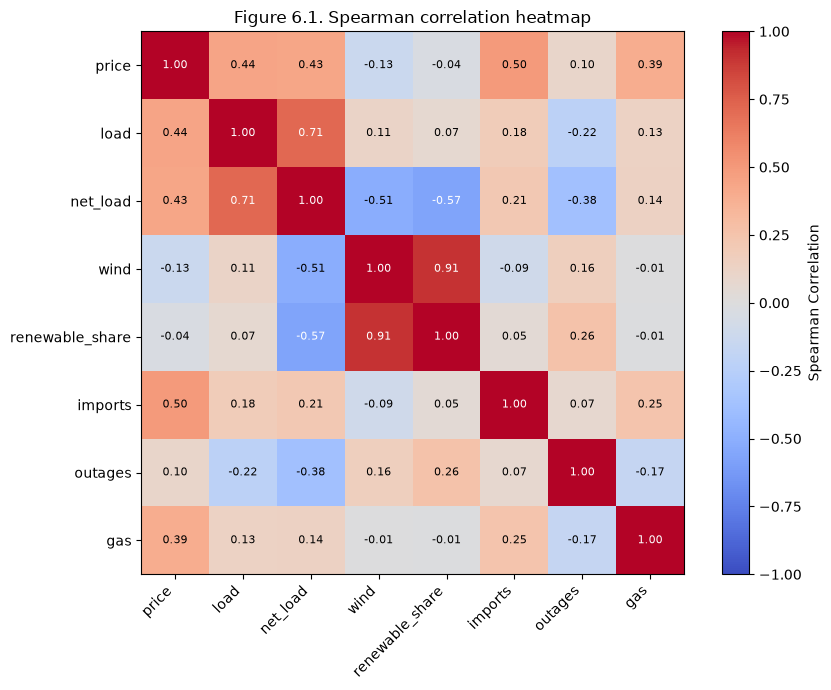

In [47]:
# ---------------------------------------------------------------------
# Visualize monotonic relationships among selected variables
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    spearman_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_title("Figure 6.1. Spearman correlation heatmap")
ax.set_xticks(range(len(spearman_corr.columns)))
ax.set_xticklabels(spearman_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(spearman_corr.index)))
ax.set_yticklabels(spearman_corr.index)

for row in range(len(spearman_corr.index)):
    for column in range(len(spearman_corr.columns)):
        value = spearman_corr.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(value) > 0.55 else "black",
        )

plt.colorbar(image, ax=ax, label="Spearman Correlation")
plt.tight_layout()
plt.show()


In [48]:
# ---------------------------------------------------------------------
# Build a compact feature ranking table for interpretation
# ---------------------------------------------------------------------

feature_observations = {
    "net_load": "Strong nonlinear relationship; best single descriptive signal examined here.",
    "imports": "Likely partly a response variable; timing and transfer limits require separate tests.",
    "gas": "Possible interaction with system tightness rather than a constant standalone effect.",
    "wind": "Negative association; value depends on season, hour, and concurrent load.",
    "outages": "Positive association but likely regime-dependent and availability-sensitive.",
    "load": "Useful baseline demand measure, but less operationally specific than net load.",
    "renewable_share": "Negative association; mechanically linked to wind, solar, and generation mix.",
}

feature_ranking = (
    pd.DataFrame({
        "variable": [
            variable
            for variable in relationship_df.columns
            if variable != "price"
        ],
        "pearson": [
            pearson_corr.loc[variable, "price"]
            for variable in relationship_df.columns
            if variable != "price"
        ],
        "spearman": [
            spearman_corr.loc[variable, "price"]
            for variable in relationship_df.columns
            if variable != "price"
        ],
    })
    .assign(
        absolute_spearman=lambda frame: frame["spearman"].abs(),
        observation=lambda frame: frame["variable"].map(feature_observations),
    )
    .sort_values("absolute_spearman", ascending=False)
    .drop(columns="absolute_spearman")
    .reset_index(drop=True)
)

feature_ranking_styled = (
    feature_ranking
    .style
    .format({
        "pearson": "{:.3f}",
        "spearman": "{:.3f}",
    })
    .set_properties(
        subset=["observation"],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "360px",
            "max-width": "520px",
        },
    )
    .set_properties(
        subset=["variable"],
        **{
            "text-align": "left",
            "min-width": "120px",
        },
    )
    .set_properties(
        subset=["pearson", "spearman"],
        **{
            "text-align": "right",
            "min-width": "80px",
        },
    )
    .set_table_attributes(
        'style="width:100%; table-layout:auto;"'
    )
)

display(feature_ranking_styled)

,variable,pearson,spearman,observation
0,imports,0.243,0.498,Likely partly a response variable; timing and transfer limits require separate tests.
1,load,0.260,0.439,"Useful baseline demand measure, but less operationally specific than net load."
2,net_load,0.307,0.433,Strong nonlinear relationship; best single descriptive signal examined here.
3,gas,0.250,0.391,Possible interaction with system tightness rather than a constant standalone effect.
4,wind,-0.170,-0.130,"Negative association; value depends on season, hour, and concurrent load."
5,outages,0.117,0.100,Positive association but likely regime-dependent and availability-sensitive.
6,renewable_share,-0.107,-0.038,"Negative association; mechanically linked to wind, solar, and generation mix."


#### Feature Ranking Table

The ranking table is a communication device rather than a feature-importance estimate. It combines Pearson and Spearman correlations with brief qualitative observations so that the strongest descriptive associations can be reviewed without implying causality, independence, or forecasting value.

#### Correlation Summary

Net load, gross load, gas prices, outages, and imports are positively associated with pool price, while wind generation and renewable share are generally negative. Spearman correlations exceed Pearson for several variables, consistent with monotonic but nonlinear or threshold-driven relationships. Because several explanatory variables are mechanically related—particularly gross load, net load, wind generation, and renewable share—correlation magnitudes should not be interpreted as measures of independent predictive importance.

Imports exhibit the strongest monotonic association with price in this sample, but contemporaneous correlation does not establish direction. Alberta may import because internal market conditions are already tight rather than imports causing higher prices. Later analyses compare lagged imports and transfer-capability utilization with contemporaneous relationships to distinguish response from potential constraint.

### 6.2 Binned Price Relationships


In [49]:
# ---------------------------------------------------------------------
# Define a reusable decile relationship summary
# ---------------------------------------------------------------------

def decile_relationship(
    data,
    feature,
    target,
    q=10,
):
    sample = data[[feature, target]].dropna().copy()

    sample["feature_decile"] = pd.qcut(
        sample[feature],
        q=q,
        labels=False,
        duplicates="drop",
    )

    summary = (
        sample.groupby("feature_decile")
        .agg(
            n_hours=(target, "size"),
            average_feature=(feature, "mean"),
            median_target=(target, "median"),
            average_target=(target, "mean"),
            p90_target=(target, lambda series: series.quantile(0.90)),
        )
    )

    return summary

,n_hours,average_feature,median_target,average_target,p90_target
feature_decile,,,,,
0,8767,7075.86,18.06,22.35,44.81
1,8766,7770.06,26.06,32.68,56.86
2,8767,8126.98,29.00,40.12,73.10
3,8766,8415.53,31.47,50.89,87.14
4,8767,8682.48,32.80,57.79,93.71
5,8766,8932.22,33.26,64.53,105.12
6,8766,9187.17,33.97,67.50,119.43
7,8767,9474.13,35.96,79.34,148.64
8,8766,9848.09,40.59,105.20,255.31


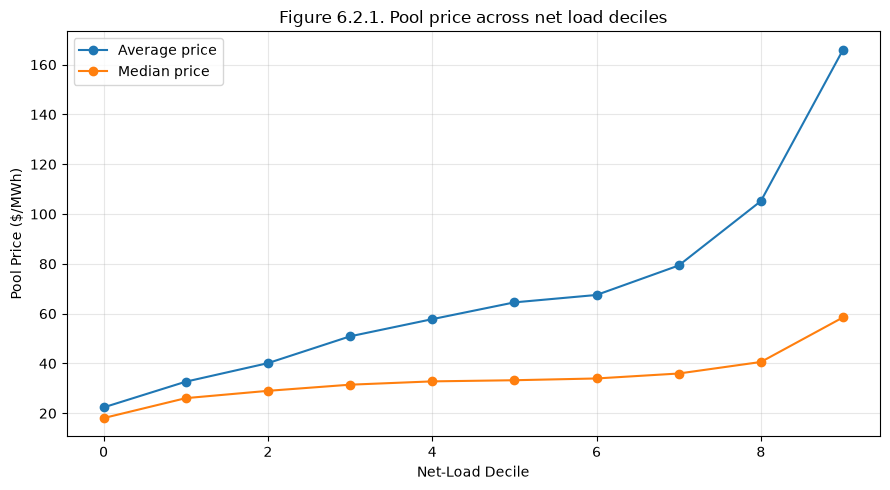

In [50]:
# ---------------------------------------------------------------------
# Summarize and visualize pool-price behaviour across net-load deciles
# ---------------------------------------------------------------------

netload_price_deciles = decile_relationship(
    relationship_df,
    "net_load",
    "price",
)

display(netload_price_deciles.round(2))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["average_target"],
    marker="o",
    label="Average price",
)
ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["median_target"],
    marker="o",
    label="Median price",
)

ax.set_title("Figure 6.2.1. Pool price across net load deciles")
ax.set_xlabel("Net-Load Decile")
ax.set_ylabel("Pool Price ($/MWh)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


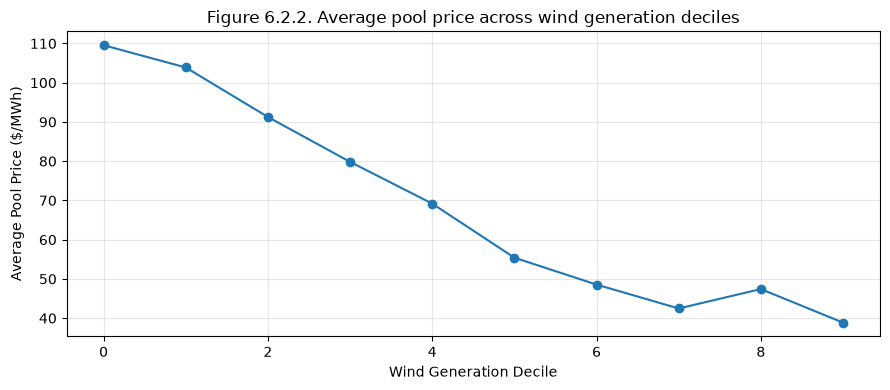

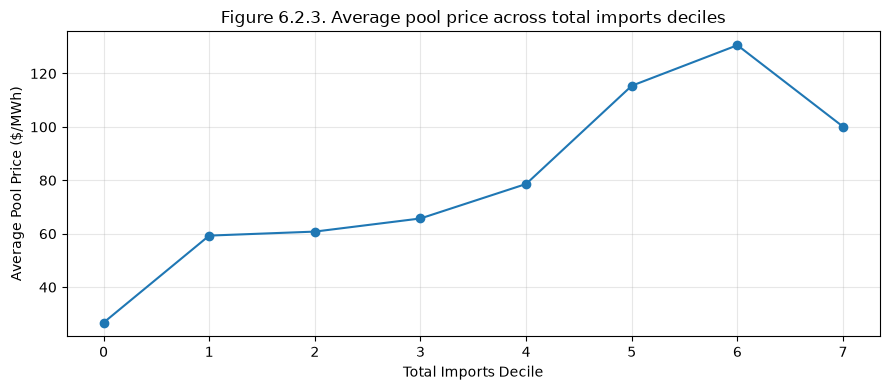

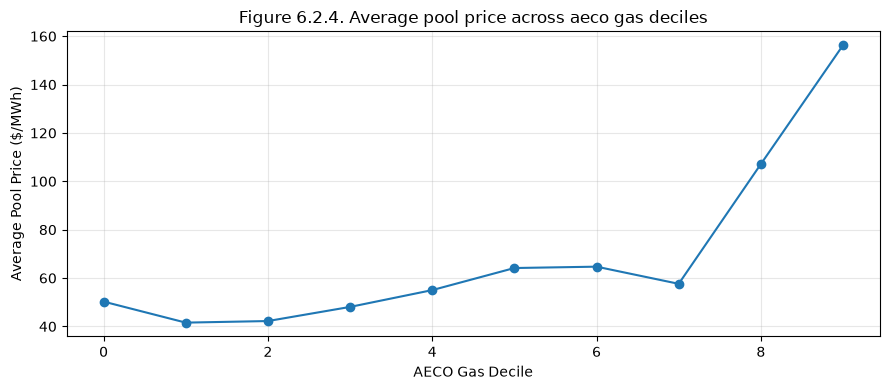

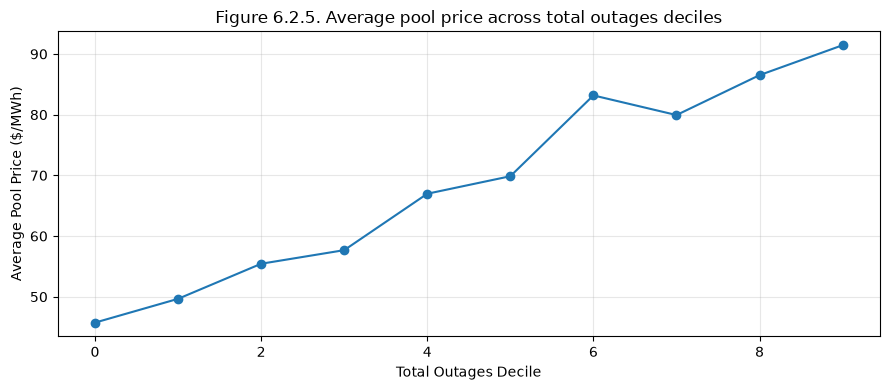

In [51]:
# ---------------------------------------------------------------------
# Compare pool-price behaviour across selected feature deciles
# ---------------------------------------------------------------------

features_to_test = {
    "Wind Generation": "wind",
    "Total Imports": "imports",
    "AECO Gas": "gas",
    "Total Outages": "outages",
}

decile_figure_numbers = {
    "Wind Generation": "6.2.2",
    "Total Imports": "6.2.3",
    "AECO Gas": "6.2.4",
    "Total Outages": "6.2.5",
}

decile_results = {}

for label, feature in features_to_test.items():
    summary = decile_relationship(relationship_df, feature, "price")
    decile_results[label] = summary

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(summary.index, summary["average_target"], marker="o")
    ax.set_title(
        f"Figure {decile_figure_numbers[label]}. "
        f"Average pool price across {label.lower()} deciles"
    )
    ax.set_xlabel(f"{label} Decile")
    ax.set_ylabel("Average Pool Price ($/MWh)")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#### Price Response Across Variable Deciles

Net load exhibits the clearest nonlinear relationship with price: average prices increase gradually through most deciles before accelerating sharply in the highest operating states. Wind generation generally aligns with lower prices, while gas prices, outages, and imports are associated with higher prices across portions of their distributions.

The gas relationship suggests a threshold effect rather than a constant marginal impact, with materially stronger price responses only at higher gas-price levels. The import relationship appears to flatten in the highest deciles, consistent with the possibility that interties approach transfer limits while prices continue to rise. These interpretations remain hypotheses and are evaluated later using interaction terms, lagged variables, and transfer-capability measures.

### 6.3 Selected Scatterplots

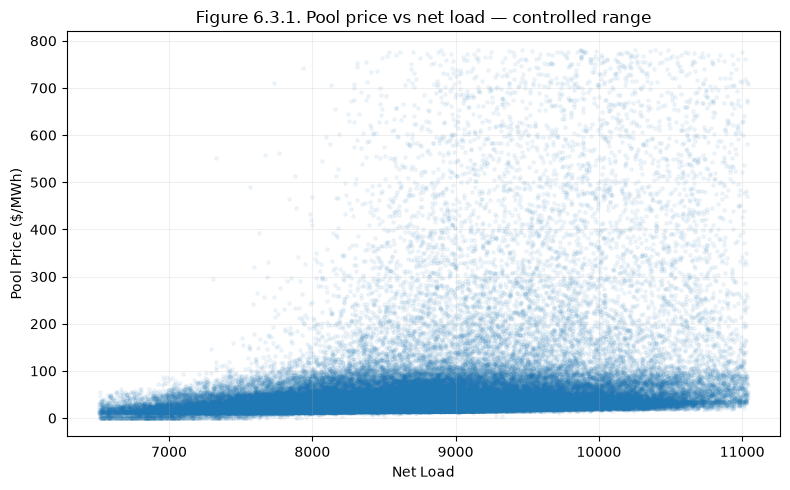

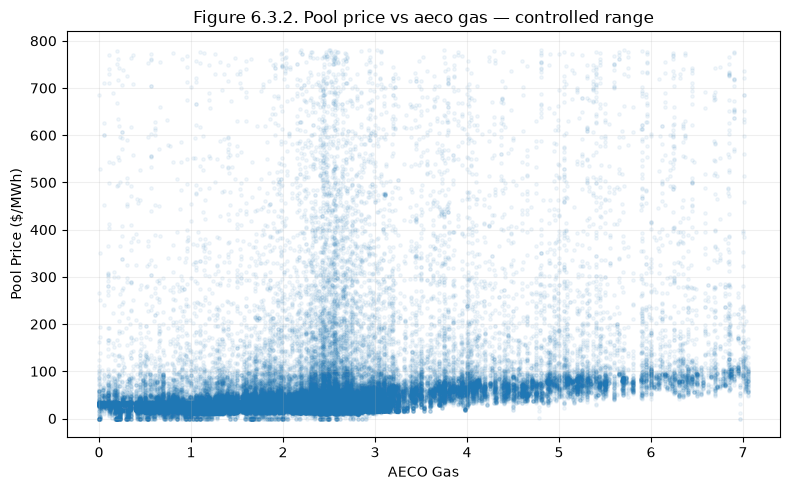

In [52]:
# ---------------------------------------------------------------------
# Visualize selected relationships within controlled display ranges
# ---------------------------------------------------------------------

scatter_features = {
    "Net Load": "net_load",
    "AECO Gas": "gas",
}

scatter_figure_numbers = {
    "Net Load": "6.3.1",
    "AECO Gas": "6.3.2",
}

scatter_samples = {}
price_upper_limit = relationship_df["price"].quantile(0.99)

for label, column in scatter_features.items():
    feature_lower_limit = relationship_df[column].quantile(0.01)
    feature_upper_limit = relationship_df[column].quantile(0.99)

    sample = (
        relationship_df.loc[
            relationship_df["price"].le(price_upper_limit)
            & relationship_df[column].between(
                feature_lower_limit,
                feature_upper_limit,
            ),
            [column, "price"],
        ]
        .dropna()
        .copy()
    )

    scatter_samples[label] = sample

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sample[column], sample["price"], alpha=0.06, s=6)
    ax.set_title(
        f"Figure {scatter_figure_numbers[label]}. "
        f"Pool price vs {label.lower()} — controlled range"
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Pool Price ($/MWh)")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


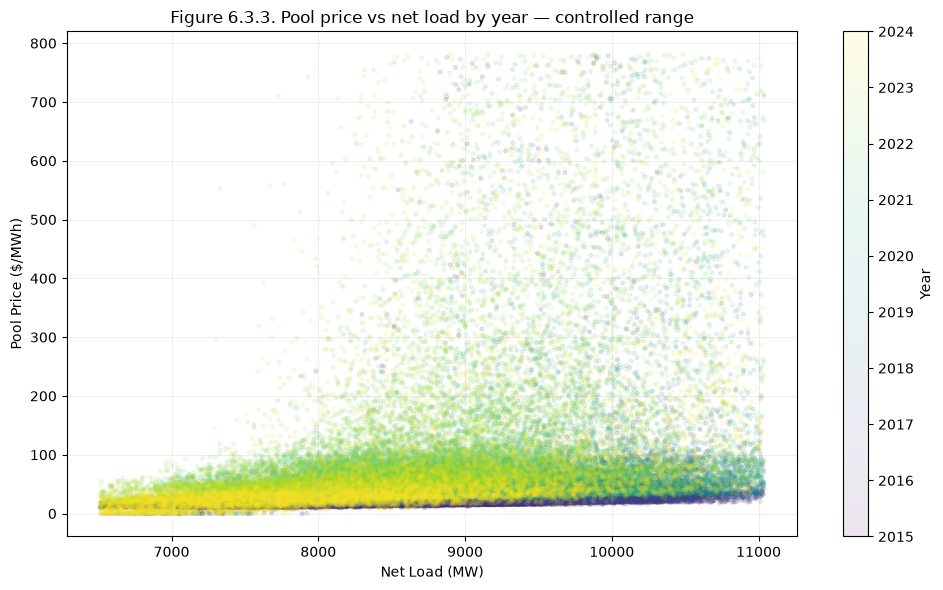

In [53]:
# ---------------------------------------------------------------------
# Visualize the net-load relationship across market regimes
# ---------------------------------------------------------------------

net_load_year_plot = pd.DataFrame({
    "net_load": net_load_for_analysis,
    "price": master["pool_price"],
    "year": master["year_alberta"],
}).dropna()

net_load_bounds = net_load_year_plot["net_load"].quantile([0.01, 0.99])
price_plot_limit = net_load_year_plot["price"].quantile(0.99)

net_load_year_plot = net_load_year_plot.loc[
    net_load_year_plot["net_load"].between(*net_load_bounds)
    & net_load_year_plot["price"].le(price_plot_limit)
]

fig, ax = plt.subplots(figsize=(10, 6))

points = ax.scatter(
    net_load_year_plot["net_load"],
    net_load_year_plot["price"],
    c=net_load_year_plot["year"],
    cmap="viridis",
    alpha=0.10,
    s=7,
)

ax.set_title("Figure 6.3.3. Pool price vs net load by year — controlled range")
ax.set_xlabel("Net Load (MW)")
ax.set_ylabel("Pool Price ($/MWh)")
ax.grid(alpha=0.2)
plt.colorbar(points, ax=ax, label="Year")

plt.tight_layout()
plt.show()


#### Scatterplot Relationships

Net load exhibits the clearest positive association with pool price, but the substantial vertical dispersion shows that similar net-load conditions can produce very different price outcomes. AECO gas displays the same limitation as a standalone explanation.

Colouring the net-load scatterplot by year shows that the relationship shifts across market regimes rather than following one stable curve. This motivates explicit regime controls, interaction terms, and time-aware validation in the forecasting analyses that follow.

## Questions Motivating the Forecasting Analysis

The exploratory analyses identify several relationships that cannot be resolved through contemporaneous descriptive statistics alone. Rather than treating these observations as established forecasting signals, the following notebooks examine how they change across operating conditions, market regimes, and forecasting horizons.

### Supply Transition, Trade, and System Adequacy

Alberta retired most of its coal generation while expanding natural gas, wind, solar, and reported maximum capacity. At the same time, the province shifted from sustained net imports toward net exports, yet high-price hours became substantially more frequent during 2021–2023.

The next stage of the analysis asks:

- Why did Alberta become a net exporter despite coal retirement and continued demand growth?
- Under what conditions was Alberta most reliant on imports during 2018–2022?
- Did the larger reported supply stack improve available system margin, or did changes in resource availability and flexibility offset the increase in nameplate capacity?
- Is available dispatchable supply relative to net load more informative than reported maximum capacity?

### Interties: Response, Price Influence, or Constraint?

Imports and pool prices exhibit similar intraday patterns and strong contemporaneous association. However, this relationship does not establish whether imports influence prices, respond to Alberta market conditions, or simply reflect a common scarcity state.

The analysis therefore asks:

- Do imports increase before Alberta prices rise, or only after internal conditions tighten?
- Does Alberta rely most heavily on imports during high net-load conditions?
- Why does the import-price relationship flatten at the highest import levels?
- Do interties become capability-constrained while Alberta prices continue rising?
- How do export conditions differ from import-dependent conditions?

### Renewable Output and the Timing of Its Value

Wind and renewable share are generally associated with lower prices, but their contribution is unlikely to be constant across seasons, hours, weather conditions, and installed capacity.

Key questions include:

- When does wind materially reduce net load and high-price risk?
- How much winter-evening net load can wind generation offset?
- Are winter-evening scarcity rates lower when wind output is strong?
- Does solar become more valuable during particular seasons, holidays, or daytime operating conditions?
- Does the predictive value of wind and solar change as renewable capacity expands?
- Why is wind more informative than total renewable share?
- Which combinations of hour, season, weather, and demand make renewable output most valuable?

### Natural Gas as a Threshold Variable

AECO gas prices exhibit only a moderate overall relationship with pool price, yet the relationship strengthens considerably during periods of unusually high gas prices.

The analysis asks:

- What conditions produce unusually high AECO prices?
- Are these episodes concentrated within particular market regimes?
- Does gas become predictive only beyond a threshold?
- Does its influence depend on net load, outages, available thermal generation, or the marginal generating technology?
- How much of the 2021–2023 high-price regime can be attributed to fuel costs rather than physical system tightness?

### Heavy Tails, Price Duration, and Market Regimes

Physical system variables occupy relatively narrow operating ranges, whereas pool price, spark spread, and some intertie measures exhibit pronounced heavy tails.

The following questions arise:

- Which heavy-tailed variables primarily reflect Alberta's internal market, and which reflect external commodity or intertie conditions?
- Are some extreme variables inherently more predictable than others?
- Has renewable integration altered the shape of the upper price tail?
- Why do annual price-duration curves differ so substantially across years?
- Did 2021–2023 represent a temporary external shock, a structural market transition, or both?

### Frequency Versus Persistence of High-Price Events

High-price hours became more frequent after 2021, but event-duration analysis also indicates that prolonged scarcity events became more common.

The analysis therefore distinguishes between event frequency and event persistence:

- Has Alberta entered scarcity conditions more often?
- Once scarcity begins, has recovery become slower?
- Do prolonged events arise from different mechanisms than isolated one-hour spikes?
- Are long events associated with persistent fuel costs, renewable conditions, outages, import limitations, or weather?
- Have both event frequency and event duration changed across market regimes?

### Seasonal and Intraday Mechanisms

High-price hours occur most frequently during late-afternoon periods and are elevated during both summer and winter.

Important questions include:

- Do summer and winter scarcity arise from different physical mechanisms?
- Which combinations of temperature, load, renewable output, outages, and intertie conditions create the highest seasonal risk?
- Is Alberta better adapted to typical winter conditions than to less common summer stress?

### Structural Change in Scarcity Predictors

Because Alberta's generation fleet, fuel mix, and trading position changed substantially between 2015 and 2024, relationships estimated across the full sample may combine several distinct market structures.

The analysis therefore asks:

- Did the relationships between net load, imports, gas prices, outages, renewable generation, and price remain stable over time?
- Did increasing renewable penetration change which operating conditions are most exposed to scarcity?
- Are the drivers of the 2021–2023 regime different from earlier high-price events?
- Should forecasting models explicitly account for changing market regimes?

## Role of This Notebook

This notebook is exploratory rather than inferential. Its analyses are primarily contemporaneous, do not control for confounding variables, and do not establish causal effects or operational forecasting performance.

Instead, the notebook identifies the central questions that motivate the remainder of the project: why scarcity increased despite a larger generation fleet, whether net load better represents system tightness than reported capacity, how imports and fuel costs interact with price formation, when renewable generation is most valuable, and how market regimes alter the relationships between system conditions and scarcity.

The following notebooks translate these questions into forecast-available features, interaction terms, availability-adjusted system-margin measures, market-regime definitions, and time-aware validation.